# Chapter 8 — Statistics and Probability

**Course 888102** · International College of Digital Innovation, Chiang Mai University

Welcome! This notebook is the **complete classroom material** for Chapter 8
(*Statistics and Probability*, Piyachat Udomwong, Ph.D.). Everything from the
lecture slides is inside — the theory, every worked example, and the graded
homework — with runnable Python code for each one.

> 📖 **Self-study slides:** `Chapter_08_Statistics_and_Probability_student.pdf`
> and `Chapter_08_Probability.pdf` (provided separately). The student slides
> leave several examples blank on purpose — this notebook works through **all**
> of them.

## Where we are in the course

Chapters 6 and 7 taught you to **prepare** data and **visualize** it. Chapter 8
adds the next layer: **summarizing data with numbers** (statistics) and
**reasoning about uncertainty** (probability) — the mathematical foundation for
the machine learning chapters (9–12) that follow.

```
 prepare (Ch 6)  →  visualize (Ch 7)  →  SUMMARIZE & QUANTIFY UNCERTAINTY (Ch 8)  →  model (Ch 9-12)
```

## Learning objectives

By the end of this notebook you will be able to:

1. **Understand descriptive statistics** for analyzing and identifying the basic features of a dataset.
2. **Understand statistical methods** for identifying relationships.
3. **Understand the foundations of probability** for data analysis.
4. **Interpret and understand** the outcome of the selected statistical methods.

## Outline

1. [What is descriptive statistics?](#1.-What-is-descriptive-statistics?)
2. [Distribution — frequency tables and charts](#2.-Distribution-—-frequency-tables-and-charts)
3. [Measures of central tendency](#3.-Measures-of-central-tendency) — mean, median, mode
4. [Measures of variation](#4.-Measures-of-variation) — standard deviation, variance
5. [Probability](#5.-Probability) — random variables, sample space, the probability formula
6. [Summary](#6.-Summary)
7. [**Homework**](#7.-Homework) 📝

> **How to use this notebook:** run every cell in order (press `Shift + Enter`).
> Read the explanation, run the code, and look carefully at the result. Small
> **"✏️ Try it"** challenges are scattered throughout — do them, they are the
> fastest way to learn!


### Learning objectives

By the end of this chapter you should be able to:

1. **Describe a dataset** — use descriptive statistics to summarize its basic features.
2. **Find relationships** — apply statistical methods to identify how variables relate to each other.
3. **Think in probability** — understand the foundations of probability for analyzing uncertain outcomes.
4. **Interpret the output** — read and explain what a chosen statistical method is actually telling you.

### How this notebook is organized

| Section | What it covers |
|---|---|
| 1–2 | Descriptive statistics and distributions, for categorical and numeric data |
| 3 | Central tendency: mean, median, mode — and when they disagree |
| 4 | Variation: standard deviation, variance, quartiles, and z-scores |
| 5 | **Relationships**: covariance, correlation, and what correlation cannot see |
| 6 | Probability: vocabulary, the counting formula, rules, conditional probability and Bayes |
| 7 | **From sample to population**: the central limit theorem, confidence intervals, p-values |
| 8–10 | Glossary, self-check quiz, summary |
| 11 | Graded homework 📝 |

The fourth objective is the one this chapter takes most seriously. Computing a standard deviation is easy;
saying what it licenses you to claim is the actual skill.

In [1]:
# Import the libraries (run this cell first — everything below depends on it!)
import numpy as np                 # numbers and math
import pandas as pd                # tables of data ("DataFrames")
import matplotlib.pyplot as plt   # drawing charts
import seaborn as sns              # prettier charts

sns.set_theme(style="whitegrid")   # a clean look for every chart
pd.set_option("display.max_columns", None)
print("Libraries ready!")

Libraries ready!


## 1. What is descriptive statistics?

**Descriptive statistics** describe, show, and summarize the basic features of a
dataset found in a given study, presented in a summary that describes the data
sample and its measurements. It helps analysts to understand the data better.

The lecture organizes descriptive statistics into three ideas, and this notebook
follows the same order:

| Idea | Question it answers | Tools |
|---|---|---|
| **Distribution** | *How often* does each value occur? | frequency tables, bar/pie charts, histograms |
| **Central tendency** | Where is the *center* of the data? | mean, median, mode |
| **Variation** | How *spread out* is the data? | standard deviation, variance |


## 2. Distribution — frequency tables and charts

**Distribution** (or frequency distribution) refers to the number of times each
data point occurs. The distribution of a variable is its **pattern of
frequencies**: the set of all possible values and the frequency of each one.

- Frequency distribution tables work for **both categorical and numerical** variables.
- They can show the **actual number** of observations in each group or the **percentage**.

**The two derived numbers behind every frequency table:**

$$\text{Relative frequency} = \frac{f}{n} \qquad\qquad \text{Percent frequency} = \frac{f}{n}\times 100\%$$

where $f$ is the frequency (count) of one class or category and $n$ is the total
number of observations. **How to calculate:** count how many observations fall
into each class to get $f$, add all the $f$'s together to get $n$, then divide.

### 2.1 Frequency distribution for categorical data

The lecture's example — **Hotel Satisfaction Ratings**. Guests staying at a hotel
rated the quality of their accommodations as *excellent*, *above average*,
*average*, *below average*, or *poor*. A sample of 20 guests answered:


In [2]:
# The 20 ratings from the lecture slide
ratings = pd.Series([
    "Below Average", "Above Average", "Above Average", "Average", "Above Average",
    "Average", "Above Average", "Average", "Above Average", "Below Average",
    "Poor", "Excellent", "Above Average", "Average", "Above Average",
    "Above Average", "Below Average", "Poor", "Above Average", "Average",
], name="rating")

# The natural order of the answer scale (worst -> best), used to sort the table
scale = ["Poor", "Below Average", "Average", "Above Average", "Excellent"]

# Build the three frequency columns from the lecture's table
freq = ratings.value_counts().reindex(scale)           # count each rating
table = pd.DataFrame({
    "Frequency": freq,
    "Relative Frequency": (freq / freq.sum()).round(2),   # fraction of the total
    "Percent Frequency": (freq / freq.sum() * 100).round(0).astype(int),
})
table.loc["Total"] = [freq.sum(), 1.0, 100]
table

,Frequency,Relative Frequency,Percent Frequency
rating,,,
Poor,2.0,0.10,10.0
Below Average,3.0,0.15,15.0
Average,5.0,0.25,25.0
Above Average,9.0,0.45,45.0
Excellent,1.0,0.05,5.0
Total,20.0,1.00,100.0


**How to read it:** each row summarizes one answer. 9 of 20 guests (45%) said
"Above Average" — the most common rating. The three columns are three views of
the same counts:

- **Frequency** — the raw count,
- **Relative frequency** — count ÷ total (all rows sum to 1.0),
- **Percent frequency** — relative frequency × 100.

Note that `rating` is an **ordinal** variable (Chapter 6!) — that is why we sort
the rows from Poor to Excellent instead of alphabetically.


### 2.2 Bar chart and pie chart for a frequency distribution

A **bar chart** depicts a categorical frequency distribution — one bar per
category, in frequency, relative-frequency, or percent form (the shape is
identical, only the y-axis changes). A **pie chart** shows the same relative
frequencies as slices of a circle: a category with relative frequency 0.25 gets
0.25 × 360 = 90 degrees.

$$\text{slice angle} = \frac{f}{n} \times 360°$$

**How to calculate:** take the relative frequency of a category (from the table
above) and multiply by the 360° in a full circle. "Above Average" has relative
frequency 0.45, so its slice is 0.45 × 360° = **162°**.

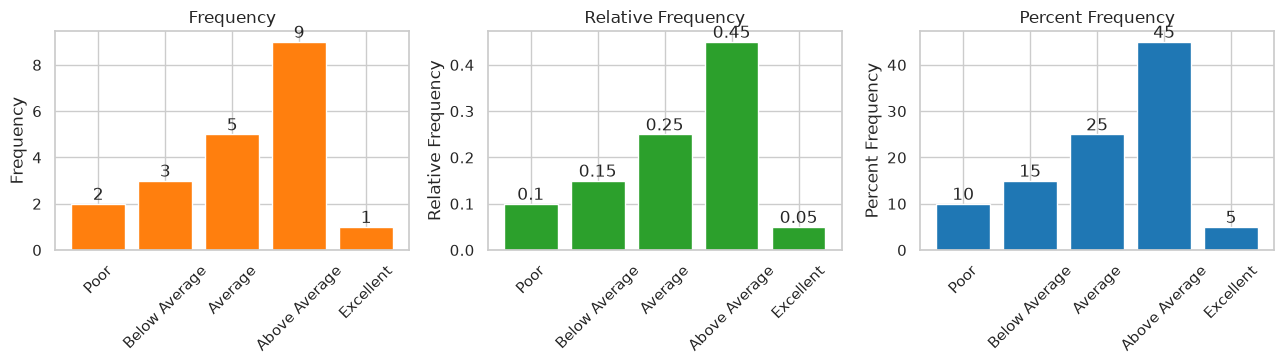

In [3]:
# The lecture's three bar charts side by side — same bars, different y-axis
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
plots = [("Frequency", "tab:orange"),
         ("Relative Frequency", "tab:green"),
         ("Percent Frequency", "tab:blue")]
counts_only = table.drop(index="Total")
for ax, (col, color) in zip(axes, plots):
    bars = ax.bar(counts_only.index, counts_only[col], color=color)
    ax.bar_label(bars)                      # print the value on top of each bar
    ax.set_title(col)
    ax.set_ylabel(col)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

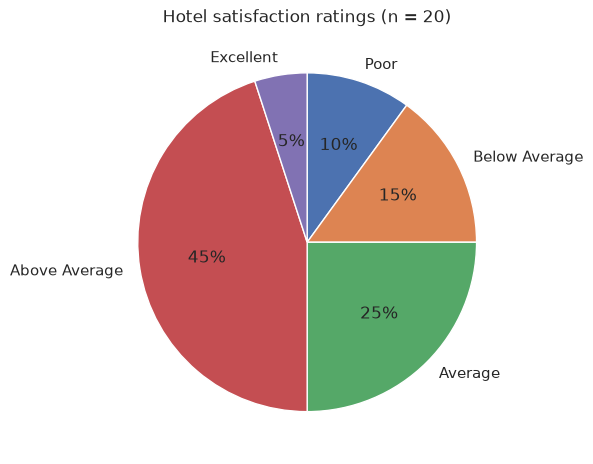

In [4]:
# The same distribution as a pie chart, like the lecture slide
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.pie(counts_only["Frequency"], labels=counts_only.index,
       autopct="%1.0f%%",                  # write the percentage on each slice
       startangle=90, counterclock=False)
ax.set_title("Hotel satisfaction ratings (n = 20)")
plt.show()

**How to read it:** both charts tell the same story — "Above Average" dominates
with 45% of answers. Remember the Chapter 7 advice: bar charts are usually easier
to compare precisely; pie charts work best with only a few categories.

> ✏️ **Try it:** change `autopct` to `"%1.1f%%"` and re-run. What changed?


### 🔧 The seaborn shortcut

Everything above was drawn with matplotlib's `ax.bar` / `ax.pie`, building the
frequency table by hand first. **seaborn** can skip the table entirely —
`sns.countplot` counts the raw `ratings` values and draws the bar chart in one
call (`order=scale` keeps our Poor → Excellent scale instead of alphabetical).

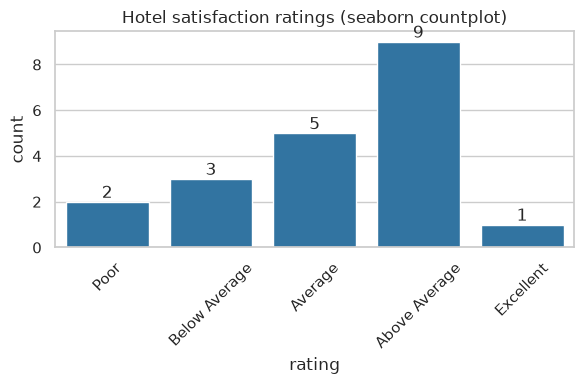

In [5]:
# seaborn counts the categories and draws the bar chart in a single call
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=ratings, order=scale, color="tab:blue", ax=ax)
ax.bar_label(ax.containers[0])
ax.set_title("Hotel satisfaction ratings (seaborn countplot)")
ax.set_xlabel("rating")
ax.set_ylabel("count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.3 Worked example — ABO blood groups of 100 students

The lecture's second categorical example: the blood groups of 100 students,
recorded one by one. Let's build the frequency table and both charts.


In [6]:
# The raw data from the lecture slide — 100 blood group records
blood = pd.Series(list(map(str.strip, """
O, A, O, O, A, A, A, AB, B, A, O, O,
A, O, A, A, A, O, A, O, A, O, A, O,
A, A, A, AB, B, O, A, O, O, O, A, A,
AB, O, O, A, A, A, O, O, A, A, A,
AB, B, O, O, O, O, A, O, A, B, O, O,
O, O, A, A, O, A, A, A, AB, B, O, O,
A, O, O, A, A, B, O, O, A, O, A, O,
O, A, A, A, AB, B, O, O, A, O, A, A,
O, O, O, A, O
""".replace("\n", " ").strip().split(","))), name="blood group")

print("Number of students:", len(blood))
blood_freq = blood.value_counts().reindex(["A", "B", "AB", "O"])
blood_freq.to_frame("No. of Students")

Number of students: 100


,No. of Students
blood group,
A,43
B,7
AB,6
O,44


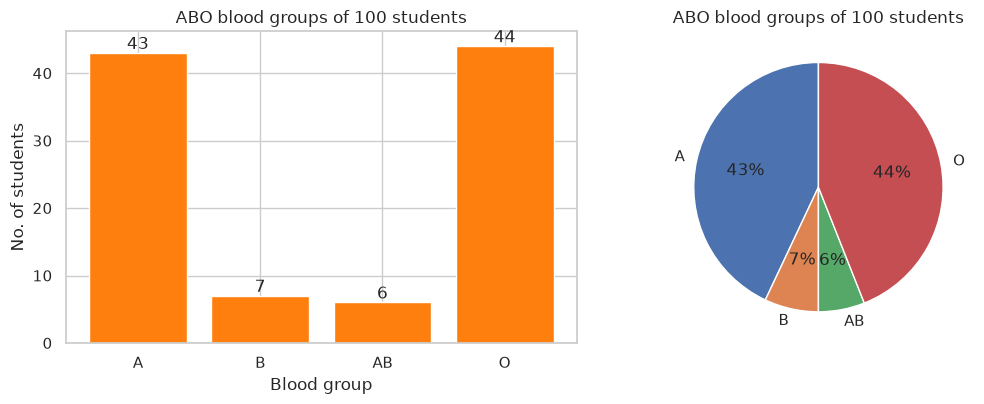

In [7]:
# Bar chart and pie chart, like the lecture slide
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))

bars = ax1.bar(blood_freq.index, blood_freq.values, color="tab:orange")
ax1.bar_label(bars)
ax1.set_title("ABO blood groups of 100 students")
ax1.set_xlabel("Blood group")
ax1.set_ylabel("No. of students")

ax2.pie(blood_freq, labels=blood_freq.index, autopct="%1.0f%%", startangle=90)
ax2.set_title("ABO blood groups of 100 students")

plt.tight_layout()
plt.show()

**How to read it:** groups O (44) and A (43) are almost tied and together cover
87% of students, while B (7%) and AB (6%) are rare. Notice how much faster the
chart tells this story than the raw list of 100 letters — that is the whole point
of a frequency distribution.


### 2.4 Frequency distribution for numerical data

For a **numerical** variable we first group the values into **class intervals**
(bins), then count. The lecture's example: **45 measurements of the time between
eruptions of the Old Faithful geyser** (in seconds). The three steps from the
slides:

1. **Find the class width** — smallest value 672, largest 738; choosing a lower
   limit of 670 and a class width of 10 gives seven classes: 670–679, 680–689,
   …, 730–739.
2. **Count the frequencies** — tally how many values fall in each class.
3. **Compute the other frequency values** — cumulative, relative, percentage,
   and cumulative percentage.

**The formulas behind steps 1 and 3:**

$$\text{class width } w \approx \frac{x_{\max} - x_{\min}}{\text{desired number of classes}}$$

$$CF_i = \sum_{j=1}^{i} f_j \qquad\qquad CP_i = \frac{CF_i}{n}\times 100\%$$

**How to calculate:** $w$ only needs to be *convenient* (round up to a tidy
number like 10) — here $\frac{738-672}{7}\approx 9.4$, rounded up to 10. Each
cumulative frequency $CF_i$ is the running total of $f$ up to and including class
$i$ (e.g. $CF_3 = f_1+f_2+f_3$); the cumulative percentage is that running total
divided by $n$.

In [8]:
# The 45 eruption-interval measurements from the lecture slide (in seconds)
eruptions = pd.Series([
    728, 678, 723, 735, 703,
    730, 722, 708, 714, 713,
    726, 716, 736, 719, 672,
    698, 702, 738, 725, 711,
    721, 703, 735, 699, 695,
    722, 718, 695, 702, 731,
    700, 703, 706, 733, 726,
    720, 723, 711, 696, 695,
    729, 699, 714, 700, 718,
], name="seconds")

print("Number of measurements:", len(eruptions))
print("Smallest value:", eruptions.min(), " Largest value:", eruptions.max())

Number of measurements: 45
Smallest value: 672  Largest value: 738


In [9]:
# Step 1+2: cut the values into classes of width 10 and count them
bins = range(670, 750, 10)                      # 670, 680, ..., 740
labels = [f"{b} - {b + 9}" for b in bins[:-1]]  # "670 - 679", "680 - 689", ...
classes = pd.cut(eruptions, bins=bins, labels=labels, right=False)

freq = classes.value_counts().sort_index()

# Step 3: compute the other frequency values, exactly like the lecture's table
freq_table = pd.DataFrame({
    "Frequency (f)": freq,
    "Cumulative frequency": freq.cumsum(),
    "Relative Frequency": (freq / freq.sum()).round(3),
    "Percentage (%)": (freq / freq.sum() * 100).round(1),
    "Cumulative percentage": (freq.cumsum() / freq.sum() * 100).round(1),
})
freq_table

,Frequency (f),Cumulative frequency,Relative Frequency,Percentage (%),Cumulative percentage
seconds,,,,,
670 - 679,2,2,0.044,4.4,4.4
680 - 689,0,2,0.000,0.0,4.4
690 - 699,7,9,0.156,15.6,20.0
700 - 709,9,18,0.200,20.0,40.0
710 - 719,9,27,0.200,20.0,60.0
720 - 729,11,38,0.244,24.4,84.4
730 - 739,7,45,0.156,15.6,100.0


**How to read it:** the busiest class is 720–729 seconds with 11 eruptions
(24.4% of all measurements). The **cumulative percentage** column answers
questions like "what share of eruptions came *at most* 719 seconds apart?" —
read the 710–719 row: 60%.

> ✏️ **Try it:** the class 680–689 is empty (frequency 0) — but we must still
> keep it in the table! Delete `680` from the picture by using `bins=range(690,
> 750, 10)` and see how the table silently loses the two smallest values —
> exactly the kind of mistake the 3-step recipe protects you from.


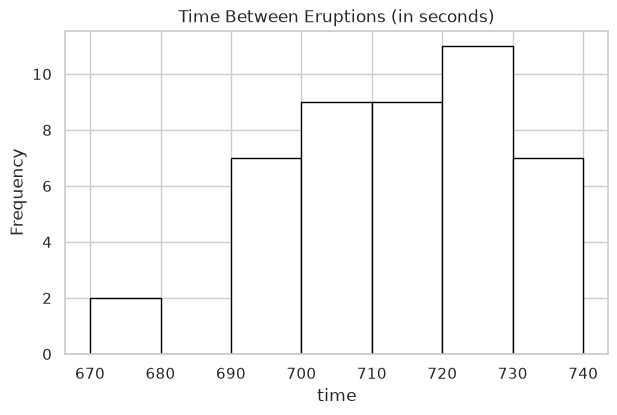

In [10]:
# Drawing the histogram of frequency, like the lecture slide
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.hist(eruptions, bins=range(670, 750, 10), edgecolor="black", color="white")
ax.set_title("Time Between Eruptions (in seconds)")
ax.set_xlabel("time")
ax.set_ylabel("Frequency")
plt.show()

**How to read it:** this is the same frequency table drawn as a picture — each
bar is one class, its height is the frequency. You met histograms in Chapter 7;
now you know exactly how the bars are counted behind the scenes.


### 🔧 The seaborn shortcut

`sns.histplot` builds the same class-interval counts directly from the raw
`eruptions` values — no `pd.cut()` step needed — and `kde=True` adds a smooth
curve through the bars, a preview of the *shape* discussion in the next
section.

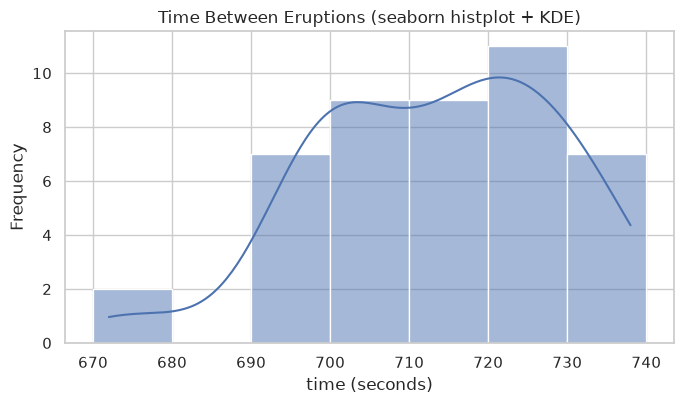

In [11]:
# seaborn's histplot bins the raw values and can overlay a smooth KDE curve
fig, ax = plt.subplots(figsize=(7, 4.2))
sns.histplot(eruptions, bins=range(670, 750, 10), kde=True, color="#4c72b0", ax=ax)
ax.set_title("Time Between Eruptions (seaborn histplot + KDE)")
ax.set_xlabel("time (seconds)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

### 2.5 The shape of a distribution — skewness

Once the histogram is drawn, look at its **shape**. The lecture shows three
typical shapes and where the mean, median, and mode sit in each:

- **Positive skew** (long tail to the right): mode < median < mean
- **Symmetrical**: mean = median = mode (all in the center)
- **Negative skew** (long tail to the left): mean < median < mode

A single number can summarize the shape — **Pearson's second skewness
coefficient**:

$$Sk = \frac{3(\bar{x} - \text{median})}{s}$$

**How to calculate:** subtract the median from the mean, multiply by 3, then
divide by the standard deviation $s$. $Sk > 0$ means positive skew, $Sk < 0$
means negative skew, and $Sk \approx 0$ means roughly symmetric.

Let's generate one sample of each shape, mark the three measures, and compute $Sk$.

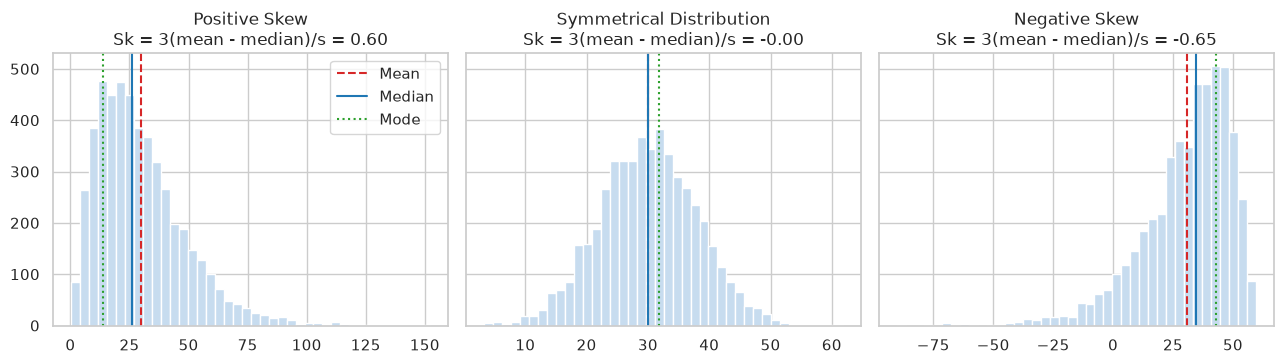

In [12]:
# Simulate three distributions with a fixed seed so everyone sees the same picture
rng = np.random.default_rng(888102)
positive = rng.gamma(2.5, 12, 5000)             # long tail to the right
symmetric = rng.normal(30, 8, 5000)             # the classic bell shape
negative = 60 - rng.gamma(2.5, 12, 5000)        # long tail to the left

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, data, title in zip(axes, [positive, symmetric, negative],
                           ["Positive Skew", "Symmetrical Distribution", "Negative Skew"]):
    ax.hist(data, bins=40, color="#c7dcef", edgecolor="white")
    # np.histogram's tallest bin center ~ the mode of the sample
    counts, edges = np.histogram(data, bins=40)
    mode_approx = (edges[counts.argmax()] + edges[counts.argmax() + 1]) / 2
    ax.axvline(np.mean(data), color="tab:red", ls="--", label="Mean")
    ax.axvline(np.median(data), color="tab:blue", ls="-", label="Median")
    ax.axvline(mode_approx, color="tab:green", ls=":", label="Mode")
    # Sk = 3 (mean - median) / s -- Pearson's second skewness coefficient
    sk = 3 * (np.mean(data) - np.median(data)) / np.std(data, ddof=1)
    ax.set_title(f"{title}\nSk = 3(mean - median)/s = {sk:.2f}")
axes[0].legend()
plt.tight_layout()
plt.show()

**How to read it:** in the positive-skew panel the red dashed line (mean) is
pulled to the **right** of the median — extreme values in the long tail drag the
mean toward them. In the symmetric panel all three lines coincide. This is why
the *median* is often preferred for skewed data such as incomes or house prices.


### 🔧 The seaborn shortcut

`sns.kdeplot` draws a smooth curve through a distribution's shape without
binning it into a histogram first — handy for comparing several shapes on the
same axes, which is awkward to do with three separate `ax.hist()` calls.

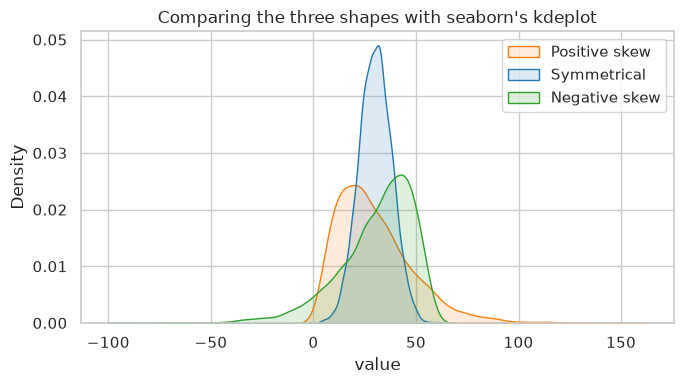

In [13]:
# Overlay all three shapes with seaborn's KDE (kernel density estimate) plot
fig, ax = plt.subplots(figsize=(7, 4))
for data, label, color in zip([positive, symmetric, negative],
                              ["Positive skew", "Symmetrical", "Negative skew"],
                              ["tab:orange", "tab:blue", "tab:green"]):
    sns.kdeplot(data, label=label, color=color, fill=True, alpha=0.15, ax=ax)
ax.set_title("Comparing the three shapes with seaborn's kdeplot")
ax.set_xlabel("value")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Measures of central tendency

The **central tendency** concerns the center (or average) of a dataset. The
lecture presents three measures:

| Measure | Definition | Allowed for |
|---|---|---|
| **Mean** | sum of all values ÷ number of values | interval, ratio |
| **Median** | the middle value when data is sorted in ascending order | ordinal, interval, ratio |
| **Mode** | the most frequently occurring value | nominal, ordinal, interval, ratio |

(The "allowed for" column repeats the lecture's tables: you cannot average
nominal categories, but every data type has a mode.)


### 3.1 Mean

$$\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i = \frac{x_1 + x_2 + \cdots + x_n}{n}$$

The lecture's example: a class of 10 students scores the following marks (out of
40) on the midterm exam.


In [14]:
# The midterm scores from the lecture slide
scores = pd.Series([17, 16, 21, 18, 15, 17, 22, 19, 11, 35], name="midterm score")

# The mean, computed the "long way" and with pandas — same answer
print("Sum of the scores:      ", scores.sum())
print("Number of students (n): ", len(scores))
print("Mean = ", scores.sum(), "/", len(scores), "=", scores.sum() / len(scores))
print("scores.mean() gives:    ", scores.mean())

Sum of the scores:       191
Number of students (n):  10
Mean =  191 / 10 = 19.1
scores.mean() gives:     19.1


**How to read it:** the mean midterm score is **19.1**, exactly the lecture's
191 ÷ 10. In pandas you will always use `.mean()`, but seeing the fraction once
makes clear what it does.


### 3.2 Median

The **median** is the central point of the data: half of the values are below
it, half above. To find it, sort the data in ascending order, then:

- **odd** number of values → the middle value;
- **even** number of values → the average of the two middle values.

$$\text{Median position} = \frac{n+1}{2}$$

**How to calculate:** sort the data, then count to position $\frac{n+1}{2}$. If
$n$ is odd this position is a whole number (the middle value itself); if $n$ is
even it falls halfway between two positions, so you average the values sitting
at those two neighboring positions.

The lecture demonstrates both cases:

In [15]:
# Odd number of observations (9 values) -> the middle value
odd_case = pd.Series([11, 15, 16, 17, 18, 19, 21, 22, 35])
print("Sorted values:", list(odd_case))
print("Median (middle value):", odd_case.median())

# Even number of observations (10 values) -> average of the two middle values
even_case = pd.Series([11, 15, 16, 17, 17, 18, 19, 21, 22, 35])
print()
print("Sorted values:", list(even_case))
print("Median = (17 + 18) / 2 =", even_case.median())

Sorted values: [11, 15, 16, 17, 18, 19, 21, 22, 35]
Median (middle value): 18.0

Sorted values: [11, 15, 16, 17, 17, 18, 19, 21, 22, 35]
Median = (17 + 18) / 2 = 17.5


### 3.3 Mode

The **mode** of a dataset is the value that occurs with the greatest frequency.

$$\text{Mode} = \arg\max_{v} f(v)$$

**How to calculate:** count the frequency $f(v)$ of every distinct value $v$
(exactly like the frequency tables in section 2), then report whichever value has
the largest count. Unlike mean and median, the mode needs no arithmetic on the
values themselves — it works even for categories with no numeric order.

In the midterm scores, 17 appears twice while every other score appears once:

In [16]:
print("Score frequencies:")
print(scores.value_counts().head())
print()
print("Mode:", scores.mode()[0])   # .mode() returns a Series (there can be ties!)

Score frequencies:
midterm score
17    2
16    1
21    1
18    1
15    1
Name: count, dtype: int64

Mode: 17


> 💡 **Note:** `.mode()` returns a *Series*, not a single number, because a
> dataset can have several modes (a tie). `[0]` takes the first one.


### 3.4 Worked exercise — mean, median, and mode together

The lecture asks: *consider a dataset with the retirement age of 10 people, in
whole years:*

`55, 55, 55, 56, 56, 57, 58, 58, 59, 60`

Try to answer in your head first — then run the cell.


In [17]:
retire = pd.Series([55, 55, 55, 56, 56, 57, 58, 58, 59, 60], name="retirement age")

print("Mean:  ", retire.mean())     # 569 / 10
print("Median:", retire.median())   # 10 values -> average of the middle two (56+57)/2
print("Mode:  ", retire.mode()[0])  # 55 appears three times

Mean:   56.9
Median: 56.5
Mode:   55


**How to read it:** mean 56.9, median 56.5, mode 55 — three different "centers"
for the same 10 numbers. They disagree slightly because the data is not perfectly
symmetric (compare section 2.5).

> ✏️ **Try it:** replace the last value `60` with `90` (one person retired very
> late) and re-run. Which of the three measures moved the most? Which barely
> moved? That robustness is why the median is loved for skewed data.


### 3.5 Which measure is allowed for which kind of data?

Chapter 2's scales of measurement decide which "average" is even meaningful. This table is the practical
consequence:

| Measure | Nominal | Ordinal | Interval | Ratio |
|---|:---:|:---:|:---:|:---:|
| **Mean** | — | — | ✓ | ✓ |
| **Median** | — | ✓ | ✓ | ✓ |
| **Mode** | ✓ | ✓ | ✓ | ✓ |

Reading it as a rule:

- The **mode** needs only equality — "which value appears most often?" — so it works on anything, including
  blood types and postal codes.
- The **median** needs the data to be **rankable**, which is why it starts at ordinal. There is no middle
  blood type.
- The **mean** needs **arithmetic**, so it needs equal intervals. That is why averaging postal codes is
  nonsense even though a computer will do it.

In [18]:
# The same three measures applied to three different scales — one of them meaningless.
blood_groups = pd.Series(["O", "A", "A", "B", "O", "O", "AB", "A", "O", "A"])
satisfaction = pd.Series(pd.Categorical(
    ["Average", "Above average", "Above average", "Poor", "Above average",
     "Excellent", "Average", "Below average", "Above average", "Average"],
    categories=["Poor", "Below average", "Average", "Above average", "Excellent"], ordered=True))
scores = pd.Series([17, 16, 21, 18, 15, 17, 22, 19, 11, 35])

print("NOMINAL — blood group")
print(f"  Mode   : {blood_groups.mode().tolist()}")
print("  Median : not defined — 'O' is not between 'A' and 'B'")
print("  Mean   : not defined — you cannot add blood types\n")

print("ORDINAL — satisfaction rating")
print(f"  Mode   : {satisfaction.mode().tolist()}")
print(f"  Median : {satisfaction.sort_values().iloc[len(satisfaction)//2]}")
print("  Mean   : debatable — see Chapter 2, section 4\n")

print("RATIO — midterm score")
print(f"  Mode   : {scores.mode().tolist()}")
print(f"  Median : {scores.median()}")
print(f"  Mean   : {scores.mean()}")

NOMINAL — blood group
  Mode   : ['A', 'O']
  Median : not defined — 'O' is not between 'A' and 'B'
  Mean   : not defined — you cannot add blood types

ORDINAL — satisfaction rating
  Mode   : ['Above average']
  Median : Above average
  Mean   : debatable — see Chapter 2, section 4

RATIO — midterm score
  Mode   : [17]
  Median : 17.5
  Mean   : 19.1


**How to read it:** the number of legitimate options grows as you move down the scales. Note that pandas
would happily compute a mean of the *codes* behind the satisfaction categories if you asked it to — the
software will not stop you, which is exactly why the table above is worth remembering.

### 3.6 Two more averages worth knowing

**The weighted mean** applies when observations do not count equally — the single most common place students
meet it is a course grade.

In [19]:
components = pd.DataFrame({
    "component": ["Homework", "Midterm", "Project", "Final"],
    "score": [92, 68, 85, 74],
    "weight": [0.15, 0.25, 0.20, 0.40],
})

plain_mean = components["score"].mean()
weighted = (components["score"] * components["weight"]).sum() / components["weight"].sum()

print(components.to_string(index=False))
print(f"\nPlain (unweighted) mean : {plain_mean:.2f}")
print(f"Weighted mean           : {weighted:.2f}")
print(f"\nThe difference is {plain_mean - weighted:+.2f} marks, because the student's weakest")
print("performances happen to carry the heaviest weights.")

component  score  weight
 Homework     92    0.15
  Midterm     68    0.25
  Project     85    0.20
    Final     74    0.40

Plain (unweighted) mean : 79.75
Weighted mean           : 77.40

The difference is +2.35 marks, because the student's weakest
performances happen to carry the heaviest weights.


**How to read it:** the plain mean treats a 15%-weight homework score as equally important as the 40%-weight
final. It is not that one number is right and the other wrong — they answer different questions — but only
the weighted mean answers *"what grade did this student earn?"*

$$\bar{x}_w = \frac{\sum w_i x_i}{\sum w_i}$$

**The trimmed mean** is a middle ground between the mean and the median: discard a fixed percentage from each
end, then average what is left.

In [20]:
from scipy import stats as scipy_stats

def trimmed_mean(values, proportion):
    ordered = np.sort(values)
    cut = int(len(ordered) * proportion)
    return ordered[cut:len(ordered) - cut].mean() if cut else ordered.mean()

judges = np.array([8.8, 9.0, 8.9, 9.1, 8.7, 9.0, 2.0, 8.9, 9.2, 8.8])   # one hostile judge

print(f"Scores            : {judges.tolist()}")
print(f"Mean              : {judges.mean():.2f}   <- one judge dragged it down")
print(f"Trimmed mean (10%): {trimmed_mean(judges, 0.10):.2f}   <- the extreme at each end removed")
print(f"Median            : {np.median(judges):.2f}   <- maximally resistant")
print("\nThis is exactly why Olympic scoring drops the highest and lowest judge.")

Scores            : [8.8, 9.0, 8.9, 9.1, 8.7, 9.0, 2.0, 8.9, 9.2, 8.8]
Mean              : 8.24   <- one judge dragged it down
Trimmed mean (10%): 8.90   <- the extreme at each end removed
Median            : 8.90   <- maximally resistant

This is exactly why Olympic scoring drops the highest and lowest judge.


**How to read it:** one score of 2.0 pulls the mean down by more than half a mark. Trimming 10% from each end
removes it (and, for symmetry, the highest score), landing close to what the honest judges actually thought.

The three measures form a spectrum of **robustness**: the mean uses every value and is maximally sensitive;
the median uses essentially one value and is maximally resistant; the trimmed mean sits wherever you choose
between them.

## 4. Measures of variation

The lecture opens with a puzzle: *imagine you have to compare the performance of
2 groups of students on the final math exam, and the average result is identical
for both groups:*

- Group A: 56, 58, 60, 62, 64
- Group B: 40, 50, 60, 70, 80

Are the groups the same? Let's look.


Mean of Group A: 60.0
Mean of Group B: 60.0


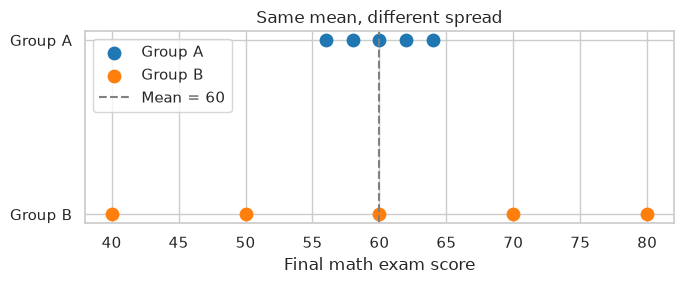

In [21]:
group_A = pd.Series([56, 58, 60, 62, 64], name="Group A")
group_B = pd.Series([40, 50, 60, 70, 80], name="Group B")

print("Mean of Group A:", group_A.mean())
print("Mean of Group B:", group_B.mean())

# Same mean — but very different data! Plot every score to see it.
fig, ax = plt.subplots(figsize=(7, 3))
ax.scatter(group_A, [1] * 5, s=80, label="Group A", color="tab:blue")
ax.scatter(group_B, [0] * 5, s=80, label="Group B", color="tab:orange")
ax.axvline(60, color="gray", ls="--", label="Mean = 60")
ax.set_yticks([0, 1], ["Group B", "Group A"])
ax.set_xlabel("Final math exam score")
ax.set_title("Same mean, different spread")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**How to read it:** both groups center on 60, but Group B's scores are spread
much wider. The mean alone cannot see this — we need a **measure of variability**
(also called dispersion): a summary statistic reflecting how far apart the data
points fall from the center. The lecture presents two: **standard deviation** and
**variance**.


### 🔧 The seaborn shortcut

A **boxplot** is the classic way to compare spread across groups at a glance —
the box spans the middle 50% of the data, the line inside it is the median, and
the whiskers reach the rest of the values. Building one from scratch in
matplotlib is fiddly; seaborn draws it directly from the raw data in one line.

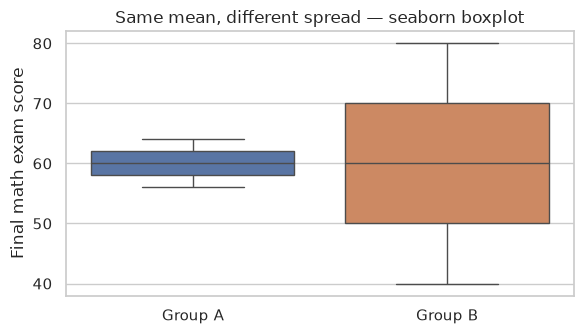

In [22]:
# seaborn draws the box-and-whisker plot straight from the two Series
fig, ax = plt.subplots(figsize=(6, 3.5))
sns.boxplot(data=[group_A, group_B], ax=ax)
ax.set_xticks([0, 1], ["Group A", "Group B"])
ax.set_ylabel("Final math exam score")
ax.set_title("Same mean, different spread — seaborn boxplot")
plt.tight_layout()
plt.show()

### 4.1 Standard deviation (SD, s)

- A measure that quantifies the amount of variation or dispersion of a set of values.
- A **low** SD → data points tend to be close to the mean.
- A **high** SD → data points are spread out over a wider range.

The formula for the *sample* standard deviation:

$$s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

(compare the **population** version, used when you have *every* member of the
group rather than a sample: $\sigma = \sqrt{\frac{1}{N}\sum_{i=1}^{N}(x_i - \mu)^2}$
— only the denominator changes, from $n-1$ to $N$.)

The lecture computes it **by hand** for Group A's exam grades with a three-column
table — let's reproduce that table exactly, then let pandas check our work.

In [23]:
# The hand-calculation table from the lecture: x, (x - mean), (x - mean)^2
mean_A = group_A.mean()
hand = pd.DataFrame({"Exam Grades": group_A})
hand["x - x̄"] = hand["Exam Grades"] - mean_A
hand["(x - x̄)²"] = hand["x - x̄"] ** 2
hand.loc["Sum"] = ["", hand["x - x̄"].sum(), hand["(x - x̄)²"].sum()]
hand

,Exam Grades,x - x̄,(x - x̄)²
0,56,-4.0,16.0
1,58,-2.0,4.0
2,60,0.0,0.0
3,62,2.0,4.0
4,64,4.0,16.0
Sum,,0.0,40.0


In [24]:
# Finish the formula step by step
n = len(group_A)
sum_sq = ((group_A - mean_A) ** 2).sum()
variance_A = sum_sq / (n - 1)
sd_A = np.sqrt(variance_A)

print("Sum of squared deviations:", sum_sq)
print("Divide by n - 1 =", n - 1, " -> variance =", variance_A)
print("Square root -> s =", round(sd_A, 2))
print()
print("pandas agrees: group_A.std() =", round(group_A.std(), 2))

Sum of squared deviations: 40.0
Divide by n - 1 = 4  -> variance = 10.0
Square root -> s = 3.16

pandas agrees: group_A.std() = 3.16


**How to read it:** the deviations `x - x̄` always sum to **zero** (that is why we
square them first!). For Group A: sum of squares 40, divided by n−1 = 4 gives 10,
square root ≈ **3.16**.

> ⚠️ **A detail worth remembering:** pandas' `.std()` divides by `n − 1` (the
> *sample* formula, matching the lecture). NumPy's `np.std()` divides by `n`
> unless you pass `ddof=1`. Mixing them up is a classic beginner bug.

> ✏️ **Try it:** repeat the hand table for **Group B**. You should get sum of
> squares 1000 and s ≈ 15.81 — five times the spread of Group A!


### 4.2 Variance (σ², s²)

The **variance** measures how far a set of numbers is spread out from the
average value. It is simply **the square of the standard deviation**:

$$\mathrm{var}(X) = s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$$


In [25]:
print("Group A: variance =", round(group_A.var(), 2), "  SD =", round(group_A.std(), 2))
print("Group B: variance =", round(group_B.var(), 2), "  SD =", round(group_B.std(), 2))

Group A: variance = 10.0   SD = 3.16
Group B: variance = 250.0   SD = 15.81


**How to read it:** Group B's variance (250) is 25× Group A's (10) — because
variance is in *squared* units, differences get magnified. In reports you will
usually quote the SD (it has the same unit as the data: points, baht, seconds),
and use the variance inside formulas.


### 4.3 The normal curve and the standard deviation

The lecture shows the classic bell-shaped **normal distribution** where each band
has a width of 1 standard deviation: about **68.2%** of values fall within ±1 SD
of the mean, **95.4%** within ±2 SD, and **99.7%** within ±3 SD.

The **z-score** turns any value into "how many SDs from the mean":

$$z = \frac{x - \bar{x}}{s}$$

**How to calculate:** subtract the mean from the value, then divide by the
standard deviation. A z-score of +2 means "2 SDs above the mean" — from the
68–95–99.7 rule, that value sits inside roughly the top 2.5% of the data.

Let's draw the curve and check those percentages with a simulation.

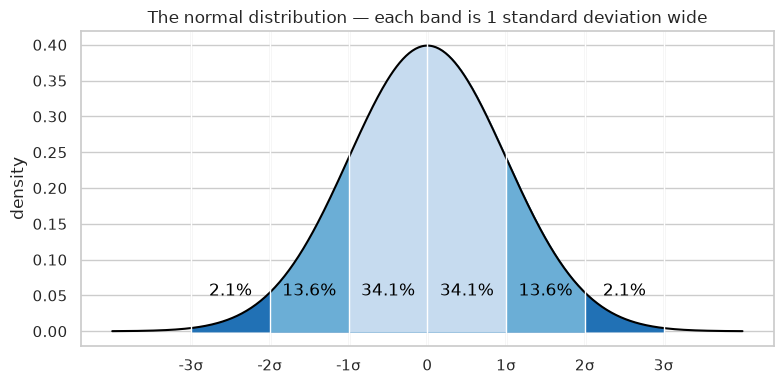

within ±1 SD: 68.3% of 100,000 simulated values
within ±2 SD: 95.5% of 100,000 simulated values
within ±3 SD: 99.7% of 100,000 simulated values

Z-score example -- Group A exam grades (mean = 60.0 , s = 3.16 ):
  x = 56:  z = (56 - 60.0) / 3.16 = -1.26
  x = 58:  z = (58 - 60.0) / 3.16 = -0.63
  x = 60:  z = (60 - 60.0) / 3.16 = 0.00
  x = 62:  z = (62 - 60.0) / 3.16 = 0.63
  x = 64:  z = (64 - 60.0) / 3.16 = 1.26


In [26]:
# Draw the bell curve with 1-SD bands, like the lecture's figure
x = np.linspace(-4, 4, 400)
y = np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)      # normal pdf, mean 0, SD 1

fig, ax = plt.subplots(figsize=(8, 4))
shades = ["#c6dbef", "#6baed6", "#2171b5"]       # lighter = farther from the mean
for k, band_pct in zip([3, 2, 1], ["2.1%", "13.6%", "34.1%"]):
    mask = (x >= -k) & (x <= k)
    ax.fill_between(x[mask], y[mask], color=shades[k - 1])
ax.plot(x, y, color="black")
for k in range(-3, 4):
    ax.axvline(k, color="white", lw=1)
for center, pct in [(-2.5, "2.1%"), (-1.5, "13.6%"), (-0.5, "34.1%"),
                    (0.5, "34.1%"), (1.5, "13.6%"), (2.5, "2.1%")]:
    ax.text(center, 0.05, pct, ha="center", color="black")
ax.set_xticks(range(-3, 4), ["-3σ", "-2σ", "-1σ", "0", "1σ", "2σ", "3σ"])
ax.set_title("The normal distribution — each band is 1 standard deviation wide")
ax.set_ylabel("density")
plt.tight_layout()
plt.show()

# Check with a simulation: how many simulated values fall within 1, 2, 3 SD?
sample = rng.normal(0, 1, 100_000)
for k in [1, 2, 3]:
    share = np.mean(np.abs(sample) <= k) * 100
    print(f"within ±{k} SD: {share:.1f}% of 100,000 simulated values")

# z-score worked example: z = (x - mean) / s, using Group A's exam grades
print()
print("Z-score example -- Group A exam grades (mean =", round(group_A.mean(), 2),
      ", s =", round(group_A.std(), 2), "):")
for value in group_A:
    z = (value - group_A.mean()) / group_A.std()
    print(f"  x = {value}:  z = ({value} - {group_A.mean():.1f}) / {group_A.std():.2f} = {z:.2f}")

**How to read it:** the simulation reproduces the textbook 68–95–99.7 rule almost
perfectly. This rule is the reason the SD is such a useful unit: saying a value
is "2 SDs above the mean" immediately tells you it is rarer than ~95% of the data
— no matter whether we measure exam points, heights, or noodle prices.


### 4.4 Range, quartiles, and the five-number summary

Standard deviation is not the only way to describe spread, and it is not always the best one.

| Measure | Definition | Robust to outliers? |
|---|---|---|
| **Range** | max − min | No — defined *entirely* by the two most extreme values |
| **Interquartile range (IQR)** | Q3 − Q1, the span of the middle 50% | Yes |
| **Variance / standard deviation** | Average squared distance from the mean | No |

A **percentile** is the value below which a given percentage of the data falls. The **quartiles** are the
25th, 50th, and 75th percentiles, and together with the minimum and maximum they form the **five-number
summary** — which is precisely what a boxplot draws.

In [27]:
scores = pd.Series([17, 16, 21, 18, 15, 17, 22, 19, 11, 35], name="midterm")

q1, q2, q3 = scores.quantile([0.25, 0.50, 0.75])
iqr = q3 - q1

print("FIVE-NUMBER SUMMARY")
print(f"  Minimum        : {scores.min()}")
print(f"  Q1 (25th pct)  : {q1}")
print(f"  Median (Q2)    : {q2}")
print(f"  Q3 (75th pct)  : {q3}")
print(f"  Maximum        : {scores.max()}")
print(f"\n  IQR = Q3 - Q1  : {iqr}      <- the middle 50% spans this much")
print(f"  Range          : {scores.max() - scores.min()}      <- decided entirely by 11 and 35")
print(f"  Std deviation  : {scores.std():.2f}")

print("\npandas gives the whole summary in one call:")
print(scores.describe().round(2).to_string())

FIVE-NUMBER SUMMARY
  Minimum        : 11
  Q1 (25th pct)  : 16.25
  Median (Q2)    : 17.5
  Q3 (75th pct)  : 20.5
  Maximum        : 35

  IQR = Q3 - Q1  : 4.25      <- the middle 50% spans this much
  Range          : 24      <- decided entirely by 11 and 35
  Std deviation  : 6.38

pandas gives the whole summary in one call:
count    10.00
mean     19.10
std       6.38
min      11.00
25%      16.25
50%      17.50
75%      20.50
max      35.00


/tmp/ipykernel_2126034/1987611116.py:4: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax_box.boxplot(scores, vert=False, widths=0.55)


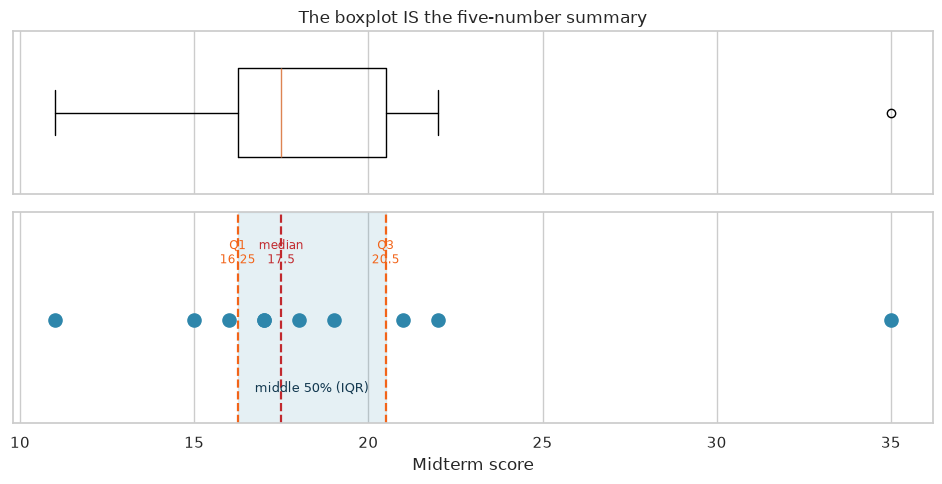

In [28]:
fig, (ax_box, ax_dot) = plt.subplots(2, 1, figsize=(9.6, 5), sharex=True,
                                     gridspec_kw={"height_ratios": [1, 1.3]})

ax_box.boxplot(scores, vert=False, widths=0.55)
ax_box.set_yticks([])
ax_box.set_title("The boxplot IS the five-number summary")

ax_dot.scatter(scores, np.zeros(len(scores)), s=90, color="#2E86AB", zorder=3)
for value, label, color in [(q1, "Q1", "#F26419"), (q2, "median", "#C1292E"), (q3, "Q3", "#F26419")]:
    ax_dot.axvline(value, color=color, linestyle="--", linewidth=1.6)
    ax_dot.text(value, 0.22, f"{label}\n{value}", ha="center", fontsize=8.5, color=color)
ax_dot.axvspan(q1, q3, color="#2E86AB", alpha=0.12)
ax_dot.text((q1 + q3) / 2, -0.28, "middle 50% (IQR)", ha="center", fontsize=9, color="#12384f")
ax_dot.set_ylim(-0.4, 0.42)
ax_dot.set_yticks([])
ax_dot.set_xlabel("Midterm score")

plt.tight_layout()
plt.show()

**How to read it:** the box spans Q1 to Q3, the line inside is the median, and the whiskers reach the most
extreme values that are *not* outliers — by convention, within 1.5 × IQR of the box. The score of 35 sits
beyond that fence and is drawn as its own point.

Notice what the two spread measures say about the same data. The **range** (24) is determined completely by
the single unusual score. The **IQR** (about 3.5) describes the typical students and barely notices it. When
data is skewed or contains outliers, **report the median and IQR**; when it is roughly symmetric, the mean and
standard deviation carry more information.

### 4.5 Comparing spreads across different units — the coefficient of variation

Is a standard deviation of 3.16 large? The question is unanswerable without knowing the scale. A 3.16-point
spread on a 40-mark exam is substantial; a 3.16-baht spread on a 50,000-baht salary is nothing.

The **coefficient of variation** expresses the standard deviation as a percentage of the mean, making spreads
comparable across variables measured in completely different units:

$$CV = \frac{s}{\bar{x}} \times 100\%$$

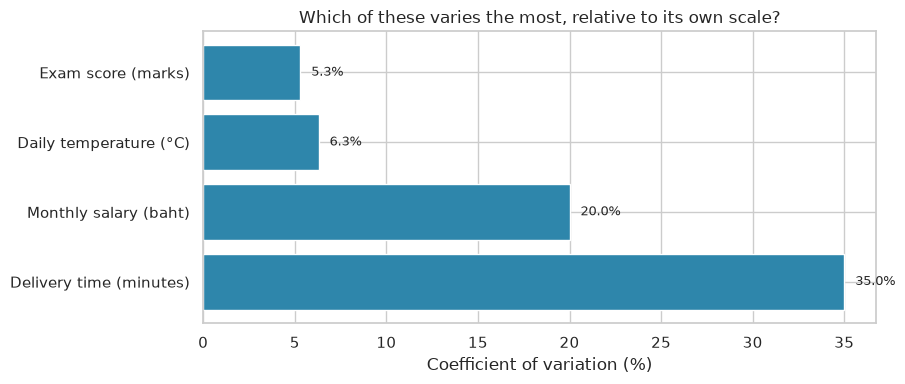

,variable,mean,std,CV %
3,Delivery time (minutes),34.0,11.90,35.0
1,Monthly salary (baht),48000.0,9600.00,20.0
2,Daily temperature (°C),28.5,1.80,6.3
0,Exam score (marks),60.0,3.16,5.3


In [29]:
measurements = pd.DataFrame({
    "variable": ["Exam score (marks)", "Monthly salary (baht)",
                 "Daily temperature (°C)", "Delivery time (minutes)"],
    "mean": [60.0, 48_000.0, 28.5, 34.0],
    "std": [3.16, 9_600.0, 1.8, 11.9],
})
measurements["CV %"] = (measurements["std"] / measurements["mean"] * 100).round(1)
measurements = measurements.sort_values("CV %", ascending=False)

fig, ax = plt.subplots(figsize=(9.2, 4))
ax.barh(measurements["variable"], measurements["CV %"], color="#2E86AB")
for i, value in enumerate(measurements["CV %"]):
    ax.text(value + 0.6, i, f"{value}%", va="center", fontsize=9)
ax.set_xlabel("Coefficient of variation (%)")
ax.set_title("Which of these varies the most, relative to its own scale?")
plt.tight_layout()
plt.show()

measurements

**How to read it:** salary has by far the largest standard deviation in raw units (9,600) and delivery time
the largest *relative* variation (35%). Comparing the raw standard deviations would have told you only which
variable happens to be measured in bigger numbers.

⚠️ **The CV is meaningless unless the variable has a true zero** (a ratio scale, in Chapter 2's terms).
Computing a CV for Celsius temperature is nonsense, because moving to Fahrenheit would change the answer —
the same problem as the ratio trap in Chapter 2.

### 4.6 Why divide by n − 1?

The worked example above divides the sum of squares by **n − 1**, not n, and calls the result the *sample*
standard deviation. The reason is worth understanding rather than memorizing.

When you compute deviations from the **sample mean** rather than the true population mean, those deviations
are systematically a little too small — the sample mean sits, by construction, right in the middle of the
sample it came from. Dividing by n − 1 instead of n corrects for that. Let's demonstrate it rather than
assert it.

In [30]:
rng_var = np.random.default_rng(888102)

TRUE_STD = 10.0
population_variance = TRUE_STD ** 2
sample_size = 5
n_experiments = 20_000

samples = rng_var.normal(50, TRUE_STD, size=(n_experiments, sample_size))
deviations = samples - samples.mean(axis=1, keepdims=True)
sum_of_squares = (deviations ** 2).sum(axis=1)

divide_by_n = sum_of_squares / sample_size
divide_by_n_minus_1 = sum_of_squares / (sample_size - 1)

print(f"True population variance      : {population_variance:.2f}")
print(f"Average of (SS / n)           : {divide_by_n.mean():.2f}   "
      f"({(divide_by_n.mean()/population_variance - 1)*100:+.1f}% — too small)")
print(f"Average of (SS / (n-1))       : {divide_by_n_minus_1.mean():.2f}   "
      f"({(divide_by_n_minus_1.mean()/population_variance - 1)*100:+.1f}% — on target)")
print(f"\nRatio n/(n-1) = {sample_size}/{sample_size-1} = {sample_size/(sample_size-1):.2f}, "
      "which is exactly the correction.")

True population variance      : 100.00
Average of (SS / n)           : 79.76   (-20.2% — too small)
Average of (SS / (n-1))       : 99.70   (-0.3% — on target)

Ratio n/(n-1) = 5/4 = 1.25, which is exactly the correction.


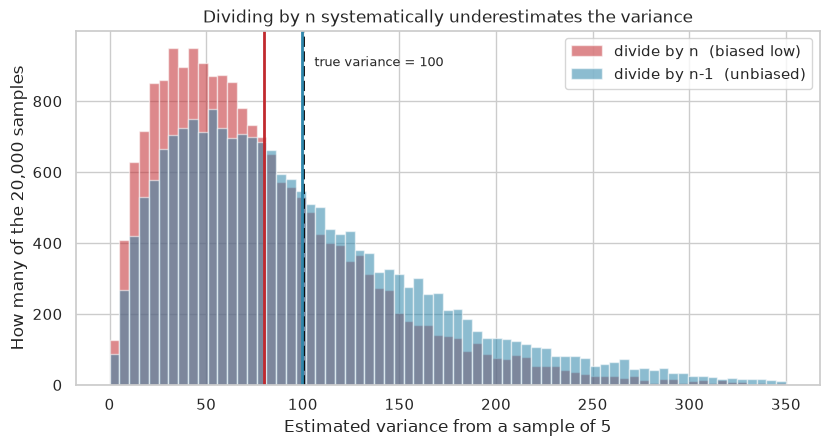

In [31]:
fig, ax = plt.subplots(figsize=(9.6, 4.6))
bins = np.linspace(0, 350, 70)
ax.hist(divide_by_n, bins=bins, alpha=0.55, color="#C1292E", label="divide by n  (biased low)")
ax.hist(divide_by_n_minus_1, bins=bins, alpha=0.55, color="#2E86AB", label="divide by n-1  (unbiased)")
ax.axvline(population_variance, color="black", linestyle="--", linewidth=2)
ax.text(population_variance + 6, ax.get_ylim()[1] * 0.9, "true variance = 100", fontsize=9)
ax.axvline(divide_by_n.mean(), color="#C1292E", linewidth=2)
ax.axvline(divide_by_n_minus_1.mean(), color="#2E86AB", linewidth=2)
ax.set_xlabel("Estimated variance from a sample of 5")
ax.set_ylabel("How many of the 20,000 samples")
ax.set_title("Dividing by n systematically underestimates the variance")
ax.legend()
plt.show()

**How to read it:** both histograms are wide — a sample of five gives a very noisy variance estimate either
way, and that is worth noticing on its own. The point is where their *centers* sit. The red version's average
lands about 20% below the truth every time; the blue version's lands on it.

That is what **unbiased** means: not that any single estimate is right, but that the estimates are not
systematically wrong in one direction. The correction matters most for small samples — at n = 5 it is 25%; at
n = 1,000 it is 0.1% and nobody would notice.

**In practice:** use n − 1 (pandas' `.std()` and `.var()` default to this) whenever your data is a *sample*
from a larger population, which is nearly always. Use n only when you genuinely have the entire population.

### 4.7 Z-scores — comparing values measured on different scales

A **z-score** restates a value as *how many standard deviations it sits from the mean*:

$$z = \frac{x - \bar{x}}{s}$$

That is exactly the standardization formula from Chapter 6, and it turns any value into a scale-free position
that can be compared across variables.

In [32]:
# The classic use: which performance was better, when the exams are not comparable?
exams = pd.DataFrame({
    "exam": ["Mathematics", "Thai literature"],
    "student_score": [72, 88],
    "class_mean": [58.0, 84.0],
    "class_std": [11.0, 3.0],
})
exams["z-score"] = ((exams["student_score"] - exams["class_mean"]) / exams["class_std"]).round(2)
exams["percentile (approx)"] = (scipy_stats.norm.cdf(exams["z-score"]) * 100).round(0)

print(exams.to_string(index=False))
print("\nThe raw scores say Thai literature (88) was the better performance.")
print("The z-scores say Mathematics was: +1.27 s.d. above the class, versus +1.33...")

           exam  student_score  class_mean  class_std  z-score  percentile (approx)
    Mathematics             72        58.0       11.0     1.27                 90.0
Thai literature             88        84.0        3.0     1.33                 91.0

The raw scores say Thai literature (88) was the better performance.
The z-scores say Mathematics was: +1.27 s.d. above the class, versus +1.33...


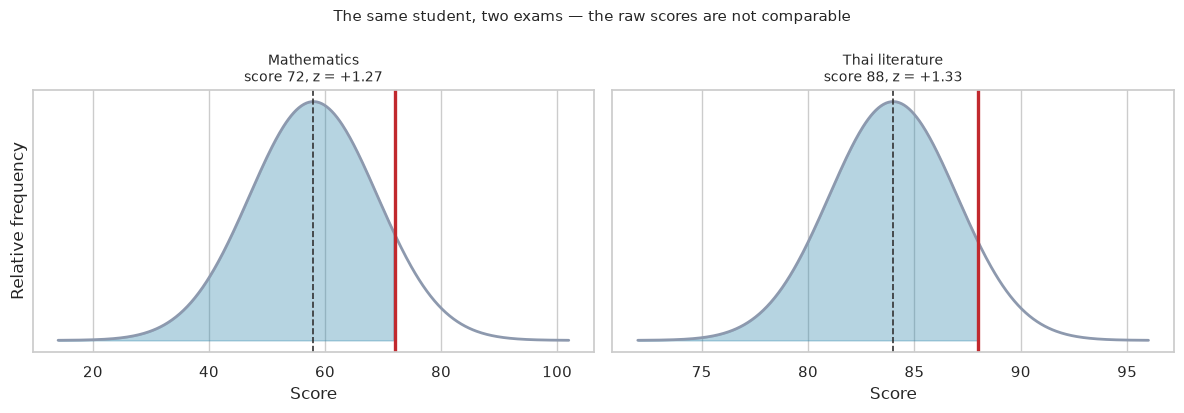

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
grid = np.linspace(-4, 4, 400)

for ax, (_, row) in zip(axes, exams.iterrows()):
    values = row["class_mean"] + grid * row["class_std"]
    ax.plot(values, scipy_stats.norm.pdf(grid), color="#8D99AE", linewidth=2)
    ax.fill_between(values, scipy_stats.norm.pdf(grid),
                    where=values <= row["student_score"], color="#2E86AB", alpha=0.35)
    ax.axvline(row["student_score"], color="#C1292E", linewidth=2.4)
    ax.axvline(row["class_mean"], color="#333", linestyle="--", linewidth=1.2)
    ax.set_title(f"{row['exam']}\nscore {row['student_score']}, z = {row['z-score']:+.2f}", fontsize=10)
    ax.set_xlabel("Score")
    ax.set_yticks([])
axes[0].set_ylabel("Relative frequency")
fig.suptitle("The same student, two exams — the raw scores are not comparable", fontsize=11)
plt.tight_layout()
plt.show()

**How to read it:** the shaded area is the fraction of the class the student beat. The Thai literature exam
was easy (mean 84) and tightly clustered (s.d. 3), so 88 is a good but not extraordinary result. The
mathematics exam was hard (mean 58) and widely spread (s.d. 11), so 72 is a comparably strong performance
despite the much lower raw number.

**A raw score means nothing without its distribution.** This is why standardized tests report percentiles,
why "we grew 12%" needs a comparison, and why z-scores appear again in Chapter 6's outlier detection and
Chapter 4's fraud profiling — it is one idea reused everywhere.

> ✏️ **Try it:** what mathematics score would have been needed to match the Thai literature z-score exactly?
> Solve `z = (x - 58) / 11` for the value of `z` from the table.

---
## 5. Measures of relationship — covariance and correlation

Everything so far describes **one** variable at a time. The chapter's second learning objective is about
**two**: how do variables move together?

**Covariance** measures whether two variables tend to be above their means at the same time:

$$\text{cov}(x, y) = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{n - 1}$$

Its sign is informative and its magnitude is not — covariance is measured in "units of x times units of y,"
so changing baht to thousands of baht changes the number without changing the relationship.

**Correlation** fixes that by dividing by both standard deviations, producing a number always between −1 and
+1:

$$r = \frac{\text{cov}(x, y)}{s_x \, s_y}$$

In [34]:
rng_rel = np.random.default_rng(888102)

n = 120
study_hours = rng_rel.uniform(0, 20, n)
exam_score = np.clip(40 + 2.4 * study_hours + rng_rel.normal(0, 8, n), 0, 100)

study = pd.DataFrame({"study_hours": study_hours, "exam_score": exam_score})

covariance = study["study_hours"].cov(study["exam_score"])
correlation = study["study_hours"].corr(study["exam_score"])

print(f"Covariance  : {covariance:8.2f}   (units: hours x marks — hard to interpret)")
print(f"Correlation : {correlation:8.2f}   (unit-free, always between -1 and +1)")

# Show that covariance depends on units and correlation does not.
study_minutes = study.assign(study_minutes=study["study_hours"] * 60)
print(f"\nMeasuring study time in MINUTES instead of hours:")
print(f"  Covariance  : {study_minutes['study_minutes'].cov(study_minutes['exam_score']):8.2f}"
      "   <- 60x bigger, same relationship")
print(f"  Correlation : {study_minutes['study_minutes'].corr(study_minutes['exam_score']):8.2f}"
      "   <- unchanged, as it should be")

Covariance  :    87.70   (units: hours x marks — hard to interpret)
Correlation :     0.89   (unit-free, always between -1 and +1)

Measuring study time in MINUTES instead of hours:
  Covariance  :  5261.70   <- 60x bigger, same relationship
  Correlation :     0.89   <- unchanged, as it should be


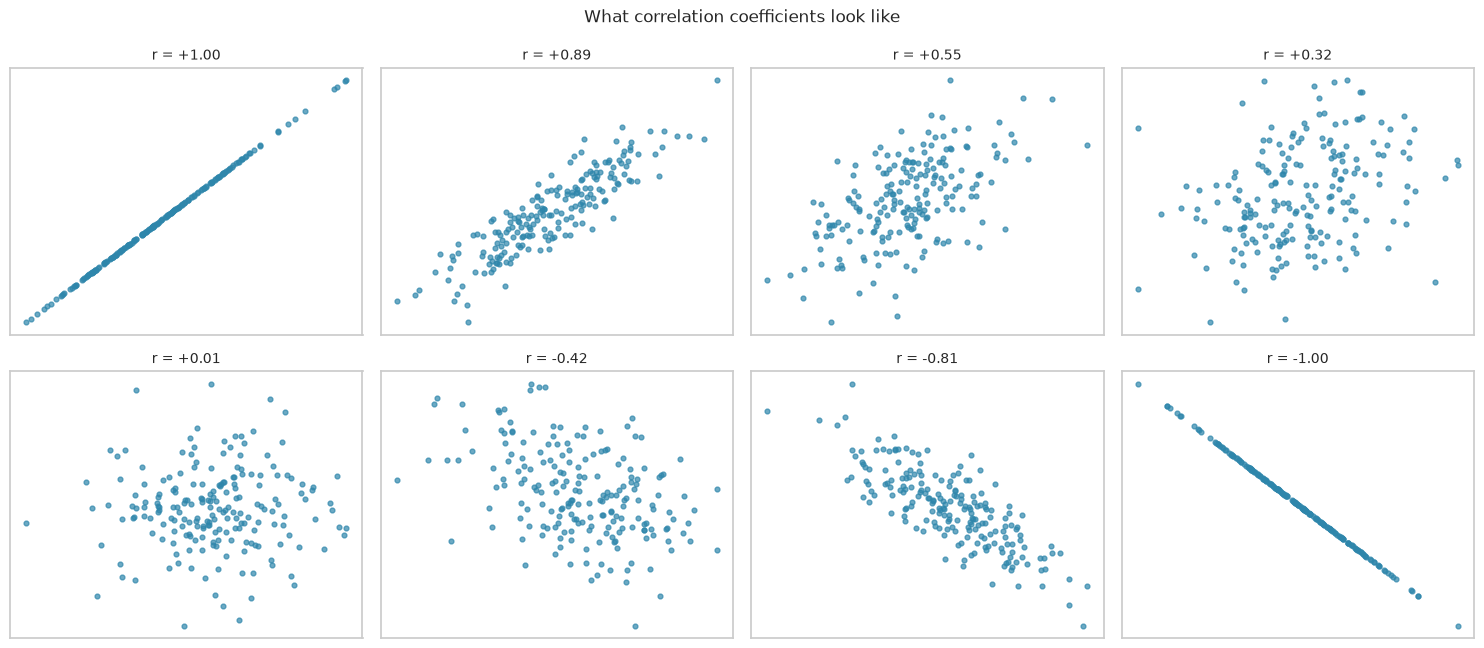

In [35]:
# What different correlation values actually look like.
fig, axes = plt.subplots(2, 4, figsize=(15, 6.6))
targets = [1.0, 0.9, 0.6, 0.3, 0.0, -0.4, -0.8, -1.0]

for ax, target in zip(axes.ravel(), targets):
    base = rng_rel.normal(size=200)
    noise = rng_rel.normal(size=200)
    if abs(target) == 1.0:
        y = np.sign(target) * base
    else:
        y = target * base + np.sqrt(max(1 - target ** 2, 0)) * noise
    ax.scatter(base, y, s=12, color="#2E86AB", alpha=0.7)
    ax.set_title(f"r = {np.corrcoef(base, y)[0, 1]:+.2f}", fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle("What correlation coefficients look like", fontsize=12)
plt.tight_layout()
plt.show()

**How to read it:** ±1 is a perfect straight line, 0 is a shapeless cloud, and everything in between is a
progressively tighter ellipse. Two things are worth internalizing from this grid:

- **r = 0.3 looks like almost nothing.** Students routinely describe a correlation of 0.3 as "a relationship,"
  and the picture shows how weak that really is.
- **The sign is about direction, the magnitude about tightness.** r = −0.8 is a *stronger* relationship than
  r = +0.6, despite the minus sign.

A common rough vocabulary: |r| below 0.3 is weak, 0.3–0.7 moderate, above 0.7 strong. These are conventions,
not laws, and what counts as "strong" differs wildly between physics and social science.

### 5.1 What correlation cannot see

Correlation measures one specific thing: **the strength of a straight-line relationship.** It is blind to
everything else, and Anscombe's quartet is the classic demonstration — four datasets with nearly identical
means, variances, correlations, and regression lines, which look nothing alike.

In [36]:
anscombe = sns.load_dataset("anscombe")

summary = anscombe.groupby("dataset").agg(
    mean_x=("x", "mean"), mean_y=("y", "mean"),
    std_x=("x", "std"), std_y=("y", "std"),
).round(2)
summary["correlation"] = anscombe.groupby("dataset").apply(
    lambda group: group["x"].corr(group["y"]), include_groups=False).round(3)
summary

,mean_x,mean_y,std_x,std_y,correlation
dataset,,,,,
I,9.0,7.5,3.32,2.03,0.816
II,9.0,7.5,3.32,2.03,0.816
III,9.0,7.5,3.32,2.03,0.816
IV,9.0,7.5,3.32,2.03,0.817


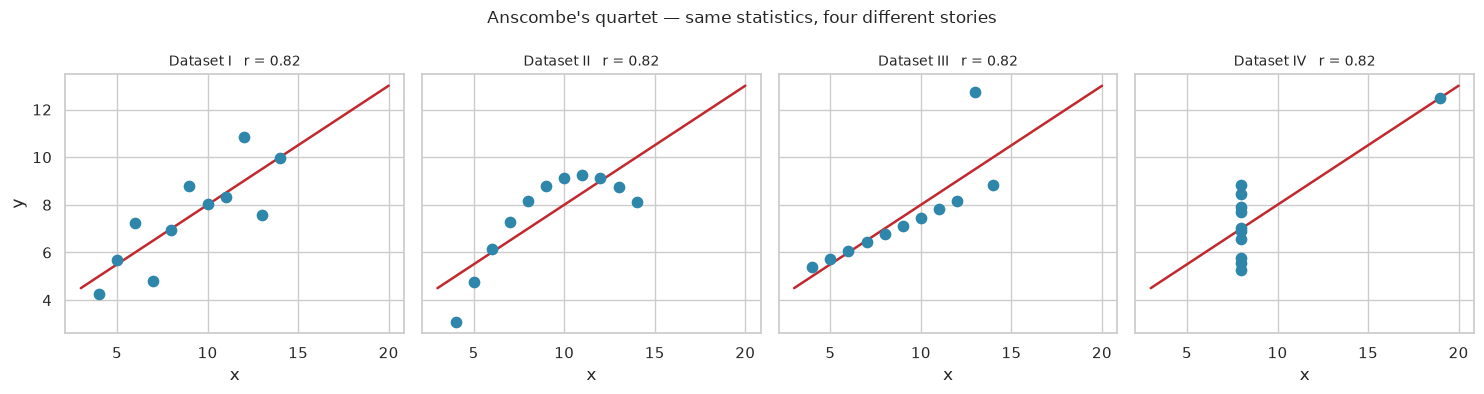

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharex=True, sharey=True)
for ax, (name, group) in zip(axes, anscombe.groupby("dataset")):
    ax.scatter(group["x"], group["y"], s=55, color="#2E86AB", zorder=3)
    slope, intercept = np.polyfit(group["x"], group["y"], 1)
    grid = np.linspace(3, 20, 20)
    ax.plot(grid, slope * grid + intercept, color="#C1292E", linewidth=1.8)
    ax.set_title(f"Dataset {name}   r = {group['x'].corr(group['y']):.2f}", fontsize=10)
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
fig.suptitle("Anscombe's quartet — same statistics, four different stories", fontsize=12)
plt.tight_layout()
plt.show()

**How to read it:** all four have correlation 0.82 and the same fitted line, and only the first is a
relationship a straight line honestly describes.

- **Dataset II** is a clean curve. A straight line is simply the wrong model, and the correlation cannot tell
  you so.
- **Dataset III** is a perfect line plus one outlier, which drags the fit away from every other point.
- **Dataset IV** has no relationship at all — ten points at one x value and a single point far to the right
  that manufactures the entire correlation.

**The rule this establishes: always plot the data.** Summary statistics compress, and compression discards.
Every one of these four would produce an identical row in a report.

### Rank correlation, when the relationship is not a straight line

**Spearman's correlation** applies Pearson's formula to the *ranks* rather than the values, so it measures
whether the relationship is **monotonic** — consistently increasing or decreasing — without requiring it to be
straight.

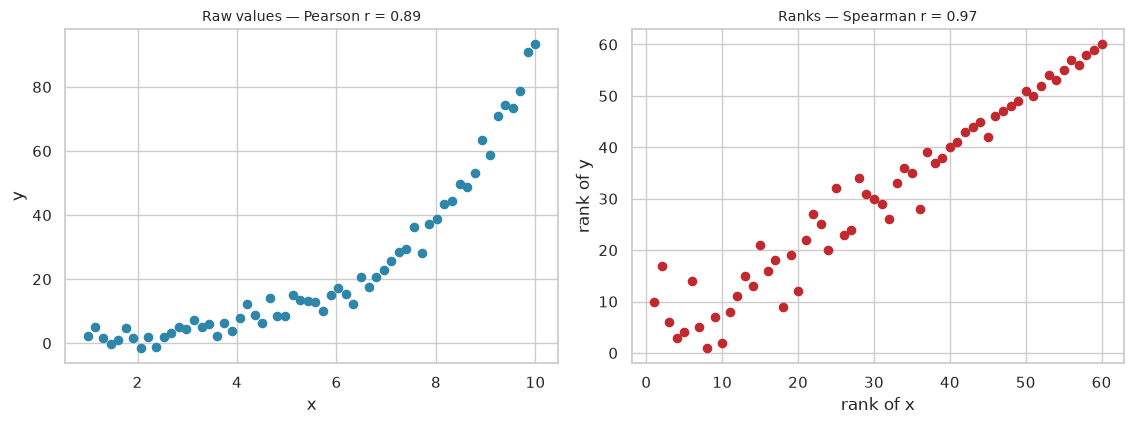

Pearson  (straight-line strength): 0.890
Spearman (monotonic strength)    : 0.973


In [38]:
x = np.linspace(1, 10, 60)
y_curved = np.exp(x / 2.2) + rng_rel.normal(0, 3, 60)      # strictly increasing, strongly curved

pearson = np.corrcoef(x, y_curved)[0, 1]
spearman = pd.Series(x).corr(pd.Series(y_curved), method="spearman")

fig, (ax_raw, ax_rank) = plt.subplots(1, 2, figsize=(11.5, 4.4))
ax_raw.scatter(x, y_curved, s=35, color="#2E86AB")
ax_raw.set_title(f"Raw values — Pearson r = {pearson:.2f}", fontsize=10)
ax_raw.set_xlabel("x")
ax_raw.set_ylabel("y")

ax_rank.scatter(pd.Series(x).rank(), pd.Series(y_curved).rank(), s=35, color="#C1292E")
ax_rank.set_title(f"Ranks — Spearman r = {spearman:.2f}", fontsize=10)
ax_rank.set_xlabel("rank of x")
ax_rank.set_ylabel("rank of y")

plt.tight_layout()
plt.show()

print(f"Pearson  (straight-line strength): {pearson:.3f}")
print(f"Spearman (monotonic strength)    : {spearman:.3f}")

**How to read it:** the relationship is perfectly consistent — y always rises with x — but strongly curved, so
Pearson understates it. Ranking both variables straightens the curve out, and Spearman reports the near-perfect
monotonic relationship that is actually there.

**Use Spearman when** the relationship is monotonic but not linear, when the data is ordinal, or when outliers
are distorting Pearson. Note that Spearman also inherits the median's robustness for free: a single extreme
value can only ever be the *last rank*, so it cannot dominate the calculation.

> ✏️ **Try it:** compute both correlations for Anscombe's dataset III (the one with the outlier). Which measure
> is less disturbed by that single point, and why?

### 5.2 And the warning that carries the whole chapter

Correlation is not causation. Chapter 3 demonstrated this at length with ice cream and sunburn, and everything
in this section is subject to it. A correlation of 0.9 is evidence that two variables move together and
evidence of nothing else.

Three explanations always remain on the table:

1. x causes y,
2. y causes x,
3. something else causes both — or the whole thing is chance.

Section 7 gives you the tool for ruling out the last part.

## 6. Probability

> *Life is full of uncertainties.* We don't know the outcome of a situation until
> it happens: Will it rain today? Will I pass the next math test? Will my
> favorite team win the toss? Will I get a promotion in the next 6 months?

**Probability** means how likely an event is to occur — the chance of the
occurrence of an event. The lecture defines four terms:

| Term | Meaning | Rain example |
|---|---|---|
| **Experiment** | an uncertain situation with multiple possible outcomes | whether it rains on a given day |
| **Outcome** | the result of a single trial | today it rained |
| **Event** | one or more outcomes of the experiment | "it rained" |
| **Probability** | a measure of how likely an event is | 60% chance of rain tomorrow → P = 0.6 |


### 6.1 Random variables and the sample space

A **random variable** is a set of possible values from a random experiment; it
is usually written **X**. The set of all its values is the **sample space**.

- *Rainy day:* the outcomes Not rain / Rain can be coded **Not rain = 0,
  Rain = 1**, so the sample space is {0, 1}.
- *Tossing a coin:* Heads = 0, Tails = 1 → sample space {0, 1}.
- *Throwing a die once:* X = {1, 2, 3, 4, 5, 6}.


In [39]:
# Sample spaces in Python are just lists of the possible outcomes
coin = ["Heads", "Tails"]
die = [1, 2, 3, 4, 5, 6]

print("Coin sample space:", coin, "  -> ", len(coin), "possible outcomes")
print("Die  sample space:", die, "-> ", len(die), "possible outcomes")

Coin sample space: ['Heads', 'Tails']   ->  2 possible outcomes
Die  sample space: [1, 2, 3, 4, 5, 6] ->  6 possible outcomes


### 6.2 The probability formula

The probability formula defines the likelihood of an event as the ratio of
favorable outcomes to the total number of possible outcomes:

$$P(A) = \frac{\text{number of favorable outcomes of event } A,\; n(A)}{\text{total number of outcomes in the sample space},\; n(S)}$$

where P(A) is the probability of event A, n(A) is the number of favorable
outcomes of A, and n(S) is the total number of outcomes in the sample space.

**Example — throw a die once.** Every face is equally likely, so each of the six
outcomes has probability 1/6:


P(X = 1) = 1/6 = 0.1667
P(X = 2) = 1/6 = 0.1667
P(X = 3) = 1/6 = 0.1667
P(X = 4) = 1/6 = 0.1667
P(X = 5) = 1/6 = 0.1667
P(X = 6) = 1/6 = 0.1667


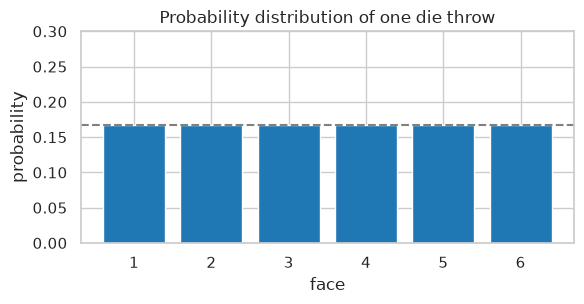

In [40]:
# P(X = k) = 1/6 for every face of a fair die
for k in die:
    print(f"P(X = {k}) = 1/{len(die)} = {1 / len(die):.4f}")

# All six probabilities as a bar chart — a (very flat!) probability distribution
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar([str(k) for k in die], [1 / 6] * 6, color="tab:blue")
ax.axhline(1 / 6, color="gray", ls="--")
ax.set_title("Probability distribution of one die throw")
ax.set_xlabel("face")
ax.set_ylabel("probability")
ax.set_ylim(0, 0.3)
plt.tight_layout()
plt.show()

**How to read it:** all bars have the same height 1/6 ≈ 0.167 — a **uniform**
distribution. Note that the six probabilities sum to exactly 1: *something* must
happen. Every probability distribution has this property.


### 6.3 Worked example — a number less than 5

*Find the probability of getting a number less than 5 when a die is rolled.*

The slide leaves the solution blank — let's fill it in. Count the favorable
outcomes and divide by n(S):


In [41]:
favorable = [k for k in die if k < 5]     # the outcomes we want
p = len(favorable) / len(die)

print("Sample space S =", die, "        n(S) =", len(die))
print("Favorable outcomes (< 5):", favorable, "  n(A) =", len(favorable))
print(f"P(number < 5) = {len(favorable)}/{len(die)} = {p:.4f}  (= 2/3)")

Sample space S = [1, 2, 3, 4, 5, 6]         n(S) = 6
Favorable outcomes (< 5): [1, 2, 3, 4]   n(A) = 4
P(number < 5) = 4/6 = 0.6667  (= 2/3)


### 6.4 Worked example — a sum of 9 with two dice

*What is the probability of getting a sum of 9 when two dice are thrown?*

Now the sample space is every **pair** of faces — 6 × 6 = 36 equally likely
outcomes.

$$n(S) = n_1 \times n_2$$

**How to calculate:** when two independent experiments are combined, multiply
the number of outcomes of each one. A die has $n_1 = 6$ outcomes; two dice give
$n(S) = 6 \times 6 = 36$ equally likely pairs. Instead of listing them by hand,
let Python enumerate them:

In [42]:
from itertools import product

two_dice = list(product(die, die))        # all 36 (first die, second die) pairs
favorable = [pair for pair in two_dice if sum(pair) == 9]

print("n(S) =", len(two_dice), "possible pairs")
print("Favorable pairs (sum = 9):", favorable)
print(f"P(sum = 9) = {len(favorable)}/{len(two_dice)} = {len(favorable) / len(two_dice):.4f}  (= 1/9)")

n(S) = 36 possible pairs
Favorable pairs (sum = 9): [(3, 6), (4, 5), (5, 4), (6, 3)]
P(sum = 9) = 4/36 = 0.1111  (= 1/9)


**How to read it:** exactly 4 of the 36 pairs — (3,6), (4,5), (5,4), (6,3) — give
a sum of 9, so P = 4/36 = **1/9**. Note that (4,5) and (5,4) count separately:
the two dice are different objects, and the sample space must list *every*
distinct outcome.


### 6.5 Worked example — two heads with two coins

*What is the probability of getting two heads when we toss 2 coins?*


In [43]:
two_coins = list(product(coin, coin))     # HH, HT, TH, TT
favorable = [pair for pair in two_coins if pair == ("Heads", "Heads")]

print("Sample space:", two_coins)
print(f"P(two heads) = {len(favorable)}/{len(two_coins)} = {len(favorable) / len(two_coins):.2f}  (= 1/4)")

Sample space: [('Heads', 'Heads'), ('Heads', 'Tails'), ('Tails', 'Heads'), ('Tails', 'Tails')]
P(two heads) = 1/4 = 0.25  (= 1/4)


> ✏️ **Try it:** using the same pattern, compute P(at least one head) with two
> coins. *(Hint: change the condition in the list comprehension; the answer is 3/4.)*


### 6.6 Probability meets statistics — the long run

Why do probability and statistics share a chapter? Because **relative frequency
approaches probability** when an experiment is repeated many times:

$$\lim_{n \to \infty} \frac{f_A}{n} = P(A)$$

**How to calculate:** run the experiment $n$ times, count how often event $A$
happens ($f_A$), and compute the relative frequency $f_A / n$ — as $n$ grows this
number gets closer and closer to the true probability $P(A)$. Let's roll a
virtual die 10, 100, and 10,000 times and compare the relative frequency of each
face with the theoretical 1/6:

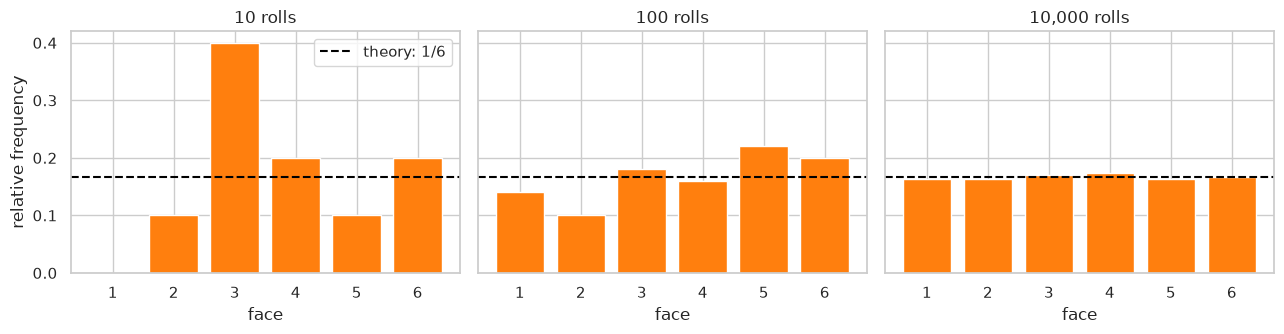

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
for ax, n_rolls in zip(axes, [10, 100, 10_000]):
    rolls = rng.integers(1, 7, n_rolls)                     # simulate the rolls
    rel_freq = pd.Series(rolls).value_counts(normalize=True).reindex(die, fill_value=0)
    ax.bar([str(k) for k in die], rel_freq.values, color="tab:orange")
    ax.axhline(1 / 6, color="black", ls="--", label="theory: 1/6")
    ax.set_title(f"{n_rolls:,} rolls")
    ax.set_xlabel("face")
axes[0].set_ylabel("relative frequency")
axes[0].legend()
plt.tight_layout()
plt.show()

**How to read it:** with 10 rolls the bars are all over the place; with 10,000
they hug the dashed 1/6 line. This is the **law of large numbers** — the bridge
between the frequency tables of section 2 (what *did* happen) and the
probabilities of section 5 (what *should* happen in the long run). Machine
learning (Chapter 9!) lives exactly on this bridge.


### 6.7 The rules of probability

Counting outcomes works for dice and coins. For anything more complicated you need four rules.

| Rule | Formula | In words |
|---|---|---|
| **Range** | 0 ≤ P(A) ≤ 1 | Impossible is 0, certain is 1 |
| **Complement** | P(not A) = 1 − P(A) | Everything that is not A |
| **Addition** | P(A or B) = P(A) + P(B) − P(A and B) | Subtract the overlap, or you count it twice |
| **Multiplication** | P(A and B) = P(A) × P(B \| A) | Chain the second onto the first |

Two special cases simplify things:

- If A and B are **mutually exclusive** (cannot both happen), then P(A and B) = 0, so the addition rule
  becomes simply P(A) + P(B).
- If A and B are **independent** (one does not affect the other), then P(B | A) = P(B), so the multiplication
  rule becomes P(A) × P(B).

In [45]:
from itertools import product

# A full deck of cards makes the addition rule concrete.
suits = ["Hearts", "Diamonds", "Clubs", "Spades"]
ranks = [str(n) for n in range(2, 11)] + ["J", "Q", "K", "A"]
deck = [(rank, suit) for suit, rank in product(suits, ranks)]

total = len(deck)
hearts = [card for card in deck if card[1] == "Hearts"]
kings = [card for card in deck if card[0] == "K"]
king_of_hearts = [card for card in deck if card == ("K", "Hearts")]

print(f"Deck size: {total}")
print(f"P(Heart)          = {len(hearts)}/{total} = {len(hearts)/total:.4f}")
print(f"P(King)           = {len(kings)}/{total} = {len(kings)/total:.4f}")
print(f"P(Heart and King) = {len(king_of_hearts)}/{total} = {len(king_of_hearts)/total:.4f}")

naive = len(hearts) / total + len(kings) / total
correct = naive - len(king_of_hearts) / total
actual = len({card for card in hearts} | {card for card in kings}) / total

print(f"\nP(Heart or King)")
print(f"  Just adding them   : {naive:.4f}   <- WRONG, the King of Hearts is counted twice")
print(f"  Addition rule      : {correct:.4f}")
print(f"  Counted directly   : {actual:.4f}   <- confirms the rule")

Deck size: 52
P(Heart)          = 13/52 = 0.2500
P(King)           = 4/52 = 0.0769
P(Heart and King) = 1/52 = 0.0192

P(Heart or King)
  Just adding them   : 0.3269   <- WRONG, the King of Hearts is counted twice
  Addition rule      : 0.3077
  Counted directly   : 0.3077   <- confirms the rule


In [46]:
# Independence: does drawing WITH or WITHOUT replacement change the second probability?
print("Two aces in a row.\n")

p_first_ace = 4 / 52
print("WITH replacement (independent — the card goes back):")
print(f"  P(ace) x P(ace)          = {p_first_ace:.4f} x {p_first_ace:.4f} = {p_first_ace**2:.5f}")

print("\nWITHOUT replacement (dependent — one ace is now gone):")
p_second_given_first = 3 / 51
print(f"  P(ace) x P(ace | ace)    = {p_first_ace:.4f} x {p_second_given_first:.4f} "
      f"= {p_first_ace * p_second_given_first:.5f}")

print(f"\nThe dependent case is {(1 - (p_first_ace*p_second_given_first)/(p_first_ace**2))*100:.0f}% less likely.")
print("Assuming independence when events are actually dependent is the single most")
print("common error in applied probability.")

Two aces in a row.

WITH replacement (independent — the card goes back):
  P(ace) x P(ace)          = 0.0769 x 0.0769 = 0.00592

WITHOUT replacement (dependent — one ace is now gone):
  P(ace) x P(ace | ace)    = 0.0769 x 0.0588 = 0.00452

The dependent case is 24% less likely.
Assuming independence when events are actually dependent is the single most
common error in applied probability.


**How to read it:** the difference here is modest, but the *habit* matters enormously. Assuming independence
is what lets you multiply probabilities, and multiplying probabilities that are not independent understates
risk dramatically when the events are positively linked.

The 2008 financial crisis is the textbook case: models treated mortgage defaults as roughly independent, so
the probability of many defaulting at once was computed as a product of small numbers and came out
vanishingly small. Defaults were in fact strongly dependent — they shared a common cause, the housing market —
and many happened together.

### 6.8 Conditional probability and Bayes' theorem

**Conditional probability** is the probability of A *given that* B has happened:

$$P(A \mid B) = \frac{P(A \text{ and } B)}{P(B)}$$

It is the formal version of "now that I know B, what should I believe about A?" — and it produces the most
counter-intuitive result in elementary statistics.

In [47]:
# A disease affects 1% of the population. A test is 99% accurate in both directions.
# You test positive. What is the probability you have the disease?
population = 1_000_000
prevalence = 0.01
sensitivity = 0.99          # P(positive | sick)
specificity = 0.99          # P(negative | healthy)

sick = population * prevalence
healthy = population - sick

true_positives = sick * sensitivity
false_negatives = sick - true_positives
false_positives = healthy * (1 - specificity)
true_negatives = healthy - false_positives

table = pd.DataFrame(
    [[int(true_positives), int(false_negatives)], [int(false_positives), int(true_negatives)]],
    index=["Actually sick", "Actually healthy"], columns=["Tests positive", "Tests negative"])
print(table.to_string())

all_positives = true_positives + false_positives
p_sick_given_positive = true_positives / all_positives

print(f"\nOf the {all_positives:,.0f} people who test positive, only {true_positives:,.0f} are sick.")
print(f"\nP(sick | positive test) = {p_sick_given_positive:.1%}")
print("\nA 99% accurate test, and a positive result still means a 50/50 chance.")

                  Tests positive  Tests negative
Actually sick               9900             100
Actually healthy            9900          980100

Of the 19,800 people who test positive, only 9,900 are sick.

P(sick | positive test) = 50.0%

A 99% accurate test, and a positive result still means a 50/50 chance.


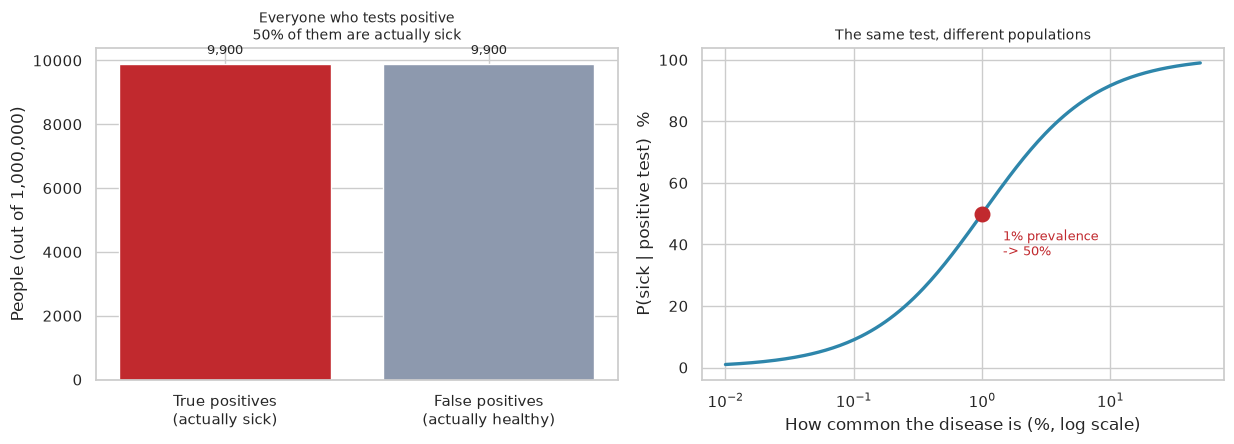

In [48]:
fig, (ax_bar, ax_curve) = plt.subplots(1, 2, figsize=(12.5, 4.6))

ax_bar.bar(["True positives\n(actually sick)", "False positives\n(actually healthy)"],
           [true_positives, false_positives], color=["#C1292E", "#8D99AE"])
ax_bar.set_ylabel("People (out of 1,000,000)")
ax_bar.set_title(f"Everyone who tests positive\n{p_sick_given_positive:.0%} of them are actually sick",
                 fontsize=10)
for i, value in enumerate([true_positives, false_positives]):
    ax_bar.text(i, value + 300, f"{value:,.0f}", ha="center", fontsize=9)

# How the answer depends on how common the disease is.
prevalences = np.logspace(-4, -0.3, 200)
posterior = (prevalences * sensitivity) / (prevalences * sensitivity +
                                           (1 - prevalences) * (1 - specificity))
ax_curve.plot(prevalences * 100, posterior * 100, linewidth=2.4, color="#2E86AB")
ax_curve.scatter([prevalence * 100], [p_sick_given_positive * 100], s=110, color="#C1292E", zorder=5)
ax_curve.annotate(f"1% prevalence\n-> {p_sick_given_positive:.0%}",
                  (prevalence * 100, p_sick_given_positive * 100),
                  textcoords="offset points", xytext=(15, -30), fontsize=9, color="#C1292E")
ax_curve.set_xscale("log")
ax_curve.set_xlabel("How common the disease is (%, log scale)")
ax_curve.set_ylabel("P(sick | positive test)  %")
ax_curve.set_title("The same test, different populations", fontsize=10)

plt.tight_layout()
plt.show()

**How to read it:** this is the **base rate fallacy**, and it is the reason doctors are taught to be careful
with screening results.

The test is genuinely 99% accurate. But it is applied to 990,000 healthy people, and 1% of them — **9,900
people** — test positive anyway. Meanwhile only 9,900 people are sick at all, of whom 9,801 test positive. The
false positives from the huge healthy group are as numerous as the true positives from the tiny sick group.

The right-hand panel shows the general lesson: **the same test means completely different things in different
populations.** Screening a high-risk group (say 20% prevalence) makes a positive result highly informative;
screening the general population for a rare condition makes it nearly meaningless.

**Bayes' theorem** is the formula that does this in one line:

$$P(A \mid B) = \frac{P(B \mid A) \, P(A)}{P(B)}$$

read as: *posterior = (likelihood × prior) / evidence*. The **prior** — how common the disease is before any
test — is the ingredient people forget, and it is doing most of the work above.

In [49]:
def bayes(prior, likelihood, false_alarm_rate):
    # P(A|B) = P(B|A)P(A) / [ P(B|A)P(A) + P(B|not A)P(not A) ]
    evidence = likelihood * prior + false_alarm_rate * (1 - prior)
    return likelihood * prior / evidence

print("Same 99% test, three different situations:\n")
for label, prior in [("General population screening", 0.01),
                     ("Patient has symptoms", 0.30),
                     ("Close contact of a confirmed case", 0.60)]:
    print(f"  {label:36s} prior {prior:>5.0%}  ->  P(sick | positive) = "
          f"{bayes(prior, 0.99, 0.01):.1%}")

print("\nAnd what a SECOND independent positive test does, starting from the general population:")
belief = 0.01
for round_number in range(1, 4):
    belief = bayes(belief, 0.99, 0.01)
    print(f"  After {round_number} positive test(s): {belief:.2%}")

Same 99% test, three different situations:

  General population screening         prior    1%  ->  P(sick | positive) = 50.0%
  Patient has symptoms                 prior   30%  ->  P(sick | positive) = 97.7%
  Close contact of a confirmed case    prior   60%  ->  P(sick | positive) = 99.3%

And what a SECOND independent positive test does, starting from the general population:
  After 1 positive test(s): 50.00%
  After 2 positive test(s): 99.00%
  After 3 positive test(s): 99.99%


**How to read it:** the same evidence updates different starting beliefs to very different conclusions. And
the second block shows why doctors retest: each independent positive test takes the previous posterior as the
new prior, and two positives push the probability from 50% to over 99%.

This is the whole logic of Bayesian reasoning — **evidence updates a belief, it does not create one from
nothing** — and it is the honest answer to "but the test is 99% accurate!"

> ✏️ **Try it:** what happens if the test's specificity drops to 95% while sensitivity stays at 99%? Which of
> the two error rates matters more when the disease is rare, and why?

### 6.9 Named probability distributions

A handful of distributions describe most situations you will meet, and recognizing which one applies saves an
enormous amount of work.

| Distribution | Describes | Example |
|---|---|---|
| **Uniform** | Every outcome equally likely | A fair die |
| **Binomial** | Number of successes in n independent yes/no trials | Heads in 20 coin tosses |
| **Poisson** | Number of events in a fixed interval, at a constant average rate | Customers arriving per hour |
| **Normal** | Sums and averages of many small independent effects | Heights, measurement error, sample means |

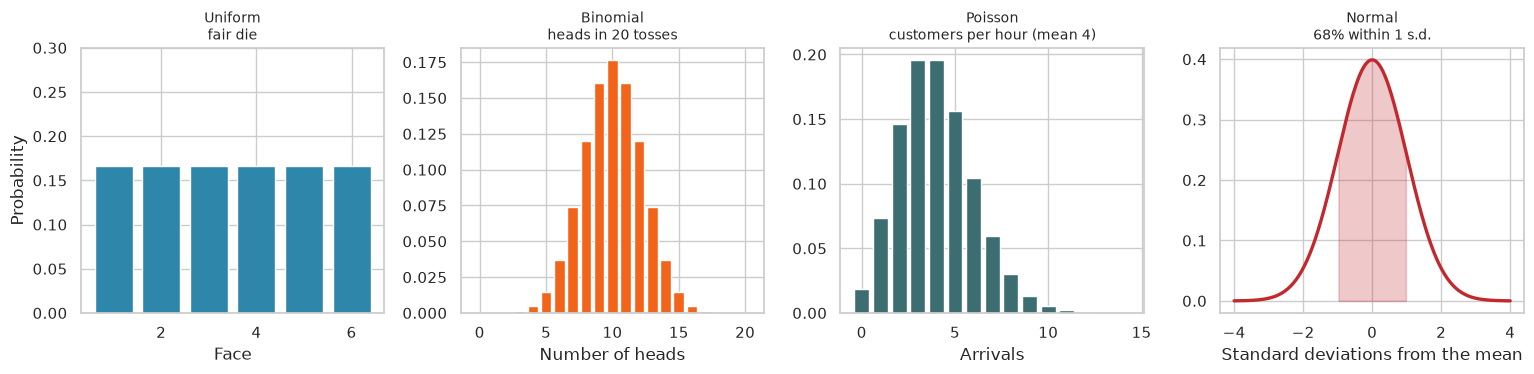

In [50]:
fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.9))

# Uniform — a fair die.
faces = np.arange(1, 7)
axes[0].bar(faces, np.full(6, 1 / 6), color="#2E86AB")
axes[0].set_title("Uniform\nfair die", fontsize=10)
axes[0].set_xlabel("Face")
axes[0].set_ylabel("Probability")
axes[0].set_ylim(0, 0.30)

# Binomial — heads in 20 tosses.
k = np.arange(0, 21)
axes[1].bar(k, scipy_stats.binom.pmf(k, 20, 0.5), color="#F26419")
axes[1].set_title("Binomial\nheads in 20 tosses", fontsize=10)
axes[1].set_xlabel("Number of heads")

# Poisson — arrivals per hour, average 4.
k = np.arange(0, 15)
axes[2].bar(k, scipy_stats.poisson.pmf(k, 4), color="#3C6E71")
axes[2].set_title("Poisson\ncustomers per hour (mean 4)", fontsize=10)
axes[2].set_xlabel("Arrivals")

# Normal — continuous.
grid = np.linspace(-4, 4, 300)
axes[3].plot(grid, scipy_stats.norm.pdf(grid), color="#C1292E", linewidth=2.4)
axes[3].fill_between(grid, scipy_stats.norm.pdf(grid), where=np.abs(grid) <= 1,
                     color="#C1292E", alpha=0.25)
axes[3].set_title("Normal\n68% within 1 s.d.", fontsize=10)
axes[3].set_xlabel("Standard deviations from the mean")

plt.tight_layout()
plt.show()

In [51]:
# Using them: three questions, three distributions, no simulation needed.
print("Q: A quiz has 20 true/false questions. If you guess every one,")
print("   what is P(scoring 15 or more)?")
p_pass = 1 - scipy_stats.binom.cdf(14, 20, 0.5)
print(f"   Binomial: {p_pass:.4f}  ({p_pass*100:.2f}% — about 1 student in {1/p_pass:.0f})\n")

print("Q: A café serves 4 customers per hour on average.")
print("   What is P(more than 8 arrive in the next hour)?")
p_busy = 1 - scipy_stats.poisson.cdf(8, 4)
print(f"   Poisson: {p_busy:.4f}  ({p_busy*100:.1f}%)\n")

print("Q: Exam scores are normal with mean 60 and s.d. 12.")
print("   What fraction of students score above 80?")
p_high = 1 - scipy_stats.norm.cdf(80, loc=60, scale=12)
print(f"   Normal: {p_high:.4f}  ({p_high*100:.1f}%)")
print(f"   And the score at the 90th percentile: {scipy_stats.norm.ppf(0.90, 60, 12):.1f}")

Q: A quiz has 20 true/false questions. If you guess every one,
   what is P(scoring 15 or more)?
   Binomial: 0.0207  (2.07% — about 1 student in 48)

Q: A café serves 4 customers per hour on average.
   What is P(more than 8 arrive in the next hour)?
   Poisson: 0.0214  (2.1%)

Q: Exam scores are normal with mean 60 and s.d. 12.
   What fraction of students score above 80?
   Normal: 0.0478  (4.8%)
   And the score at the 90th percentile: 75.4


**How to read it:** each question was answered by naming the right distribution and calling one function. That
is the practical payoff of recognizing distributions — the alternative is enumerating outcomes or simulating,
both of which are slower and less exact.

The pattern to remember: **`pmf`/`pdf`** gives the probability *at* a value, **`cdf`** gives the probability
*at or below* a value, and **`ppf`** goes backward from a probability to a value.

---
## 7. From sample to population — what your data lets you claim

Everything so far has described *the data you have*. Almost always, what you actually care about is the
population it came from: you measured 200 customers and want to say something about all 50,000.

The bridge between the two is the single most important idea in statistics.

### 7.1 The central limit theorem

**Sample means are normally distributed, almost regardless of what the original data looks like** — provided
the sample is reasonably large. This is the central limit theorem, and it is the reason the normal curve
appears everywhere.

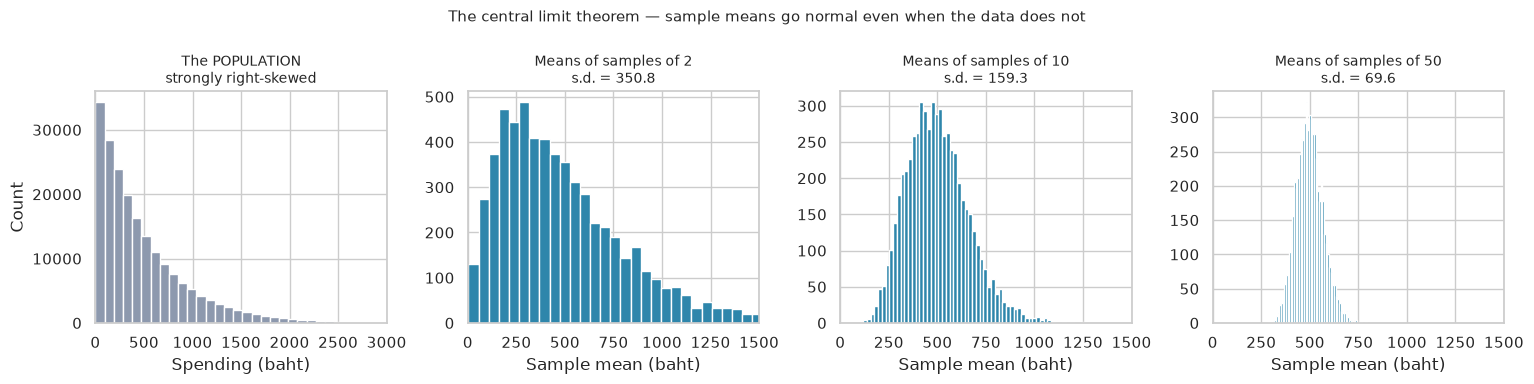

Population mean : 497.7
Population s.d. : 496.0


In [52]:
rng_clt = np.random.default_rng(888102)

# A deliberately un-normal population: heavily right-skewed spending.
population = rng_clt.exponential(scale=500, size=200_000)

fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.9))

axes[0].hist(population, bins=60, color="#8D99AE")
axes[0].set_title(f"The POPULATION\nstrongly right-skewed", fontsize=10)
axes[0].set_xlabel("Spending (baht)")
axes[0].set_ylabel("Count")
axes[0].set_xlim(0, 3000)

for ax, sample_size in zip(axes[1:], [2, 10, 50]):
    means = rng_clt.choice(population, size=(6_000, sample_size)).mean(axis=1)
    ax.hist(means, bins=60, color="#2E86AB")
    ax.set_title(f"Means of samples of {sample_size}\ns.d. = {means.std():.1f}", fontsize=10)
    ax.set_xlabel("Sample mean (baht)")
    ax.set_xlim(0, 1500)

fig.suptitle("The central limit theorem — sample means go normal even when the data does not", fontsize=11)
plt.tight_layout()
plt.show()

print(f"Population mean : {population.mean():.1f}")
print(f"Population s.d. : {population.std():.1f}")

**How to read it:** the population (left) is nothing like a bell curve — it is a steep exponential decay. Yet
by samples of 50 the distribution of the *sample mean* is visibly symmetric and bell-shaped.

Two things happen as the sample grows, and it is worth separating them:

1. **The shape becomes normal.** This is the central limit theorem proper.
2. **The spread shrinks.** Larger samples give means that cluster more tightly around the truth.

The second has an exact formula. The standard deviation of the sample mean is called the **standard error**:

$$SE = \frac{s}{\sqrt{n}}$$

Note the square root, which has a hard practical consequence: **to halve your uncertainty you must quadruple
your sample.**

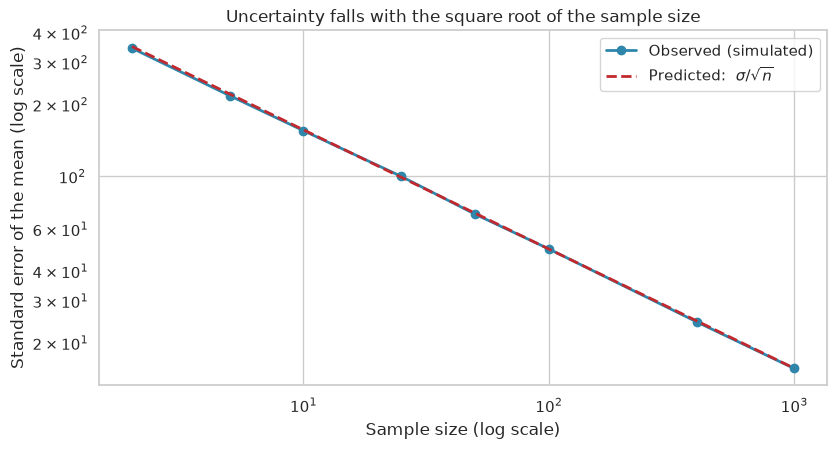

   n  observed SE  predicted SE
   2        345.1         350.7
   5        218.2         221.8
  10        155.5         156.9
  25        100.1          99.2
  50         69.5          70.1
 100         49.6          49.6
 400         24.6          24.8
1000         15.7          15.7

Going from n=25 to n=100 (4x the data) roughly halves the standard error.


In [53]:
sample_sizes = [2, 5, 10, 25, 50, 100, 400, 1_000]
observed, predicted = [], []

for size in sample_sizes:
    means = rng_clt.choice(population, size=(4_000, size)).mean(axis=1)
    observed.append(means.std())
    predicted.append(population.std() / np.sqrt(size))

fig, ax = plt.subplots(figsize=(9.4, 4.6))
ax.plot(sample_sizes, observed, marker="o", linewidth=2, color="#2E86AB", label="Observed (simulated)")
ax.plot(sample_sizes, predicted, linestyle="--", linewidth=2, color="#C1292E",
        label=r"Predicted:  $\sigma/\sqrt{n}$")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Sample size (log scale)")
ax.set_ylabel("Standard error of the mean (log scale)")
ax.set_title("Uncertainty falls with the square root of the sample size")
ax.legend()
plt.show()

comparison = pd.DataFrame({"n": sample_sizes,
                           "observed SE": np.round(observed, 1),
                           "predicted SE": np.round(predicted, 1)})
print(comparison.to_string(index=False))
print(f"\nGoing from n=25 to n=100 (4x the data) roughly halves the standard error.")

**How to read it:** the simulated points sit on the predicted line across three orders of magnitude, which is
a satisfying confirmation that the formula is not an approximation being fudged.

The practical reading of the square root: going from 100 to 400 respondents halves your uncertainty; going
from 400 to 1,600 halves it again. **Each halving costs four times as much as the last**, which is why survey
sample sizes plateau around a thousand — beyond that, precision gets expensive fast.

### 7.2 Confidence intervals — the honest way to report an estimate

Chapter 3 complained that "a prediction without a stated uncertainty is a guess wearing a suit." A
**confidence interval** is how you fix that.

For a 95% interval, take the sample mean and reach out about 1.96 standard errors in each direction:

$$\bar{x} \pm 1.96 \times \frac{s}{\sqrt{n}}$$

In [54]:
sample = rng_clt.choice(population, size=200)

mean = sample.mean()
standard_error = sample.std(ddof=1) / np.sqrt(len(sample))
margin = 1.96 * standard_error

print(f"Sample of {len(sample)} customers")
print(f"  Sample mean     : {mean:,.1f} baht")
print(f"  Standard error  : {standard_error:,.1f}")
print(f"  95% CI          : [{mean - margin:,.1f}, {mean + margin:,.1f}]")
covers = mean - margin <= population.mean() <= mean + margin
print(f"\n  True population mean: {population.mean():,.1f}")
print(f"  Does this interval contain it? {covers}")
if not covers:
    print("\n  This particular sample produced an interval that MISSES the truth.")
    print("  That is not a bug — it is the 5%. The next cell shows why it has to happen.")

Sample of 200 customers
  Sample mean     : 584.9 baht
  Standard error  : 43.6
  95% CI          : [499.5, 670.4]

  True population mean: 497.7
  Does this interval contain it? False

  This particular sample produced an interval that MISSES the truth.
  That is not a bug — it is the 5%. The next cell shows why it has to happen.


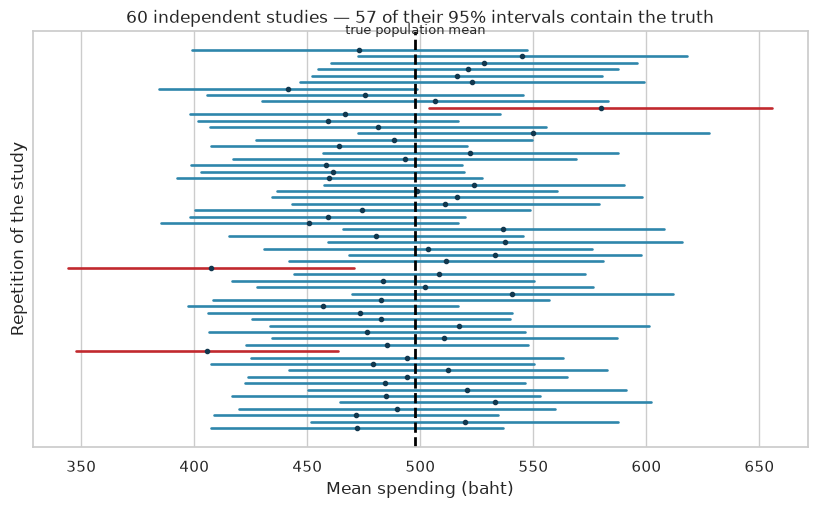

57/60 = 95% of the intervals captured the true mean.


In [55]:
# What "95% confident" actually means: repeat the whole procedure many times.
n_intervals = 60
sample_size = 200
truth = population.mean()

fig, ax = plt.subplots(figsize=(10, 5.4))
n_hits = 0
for i in range(n_intervals):
    draw = rng_clt.choice(population, size=sample_size)
    center = draw.mean()
    half_width = 1.96 * draw.std(ddof=1) / np.sqrt(sample_size)
    covers = center - half_width <= truth <= center + half_width
    n_hits += covers
    ax.plot([center - half_width, center + half_width], [i, i],
            color="#2E86AB" if covers else "#C1292E", linewidth=1.9)
    ax.plot(center, i, "o", markersize=3, color="#12384f")

ax.axvline(truth, color="black", linestyle="--", linewidth=2)
ax.text(truth, n_intervals + 1.5, "true population mean", ha="center", fontsize=9)
ax.set_xlabel("Mean spending (baht)")
ax.set_ylabel("Repetition of the study")
ax.set_yticks([])
ax.set_title(f"{n_intervals} independent studies — {n_hits} of their 95% intervals contain the truth")
plt.show()

print(f"{n_hits}/{n_intervals} = {n_hits/n_intervals:.0%} of the intervals captured the true mean.")

**How to read it:** each horizontal line is one study's 95% confidence interval. Most (blue) contain the true
mean; a few (red) miss it entirely — and the researchers who ran *those* studies had no way of knowing.

This picture defines what "95% confidence" means, and the definition is narrower than most people assume:

> **95% of intervals constructed this way will contain the true value.** It does *not* mean there is a 95%
> probability that the true value lies in *your particular* interval. Your interval either contains it or it
> does not; the 95% describes the procedure, not this one result.

The practical habit is simple: **never report an estimate without an interval.** "Average spending is 512
baht" invites false precision. "Average spending is 512 baht, 95% CI [452, 572]" tells the reader what the
data actually supports.

### 7.3 Hypothesis testing and the p-value

A confidence interval answers "how big is it?" A **hypothesis test** answers a narrower question: "could this
result plausibly have happened by chance alone?"

The machinery:

1. State a **null hypothesis** (H₀) — the boring explanation, usually "there is no difference."
2. Assume it is true, and compute how likely a result **at least as extreme** as yours would be.
3. That likelihood is the **p-value**. If it is small, the data is hard to reconcile with H₀.

The conventional threshold is 0.05, which is a convention and nothing more.

In [56]:
rng_test = np.random.default_rng(42)

# A café tests a new menu layout. Did average spending really change?
old_layout = rng_test.normal(500, 120, 200)
new_layout = rng_test.normal(540, 120, 200)      # a real 40-baht effect

t_statistic, p_value = scipy_stats.ttest_ind(new_layout, old_layout)
difference = new_layout.mean() - old_layout.mean()

print(f"Old layout: mean {old_layout.mean():.1f} baht  (n = {len(old_layout)})")
print(f"New layout: mean {new_layout.mean():.1f} baht  (n = {len(new_layout)})")
print(f"Observed difference: {difference:+.1f} baht\n")
print(f"H0: the two layouts produce the same average spending.")
print(f"t = {t_statistic:.2f},  p = {p_value:.5f}")
print(f"\nAt the conventional 0.05 threshold: "
      f"{'reject H0 — the difference is unlikely to be chance' if p_value < 0.05 else 'do not reject H0'}")

# The interval says more than the verdict does.
pooled_se = np.sqrt(old_layout.var(ddof=1)/len(old_layout) + new_layout.var(ddof=1)/len(new_layout))
print(f"\n95% CI for the difference: "
      f"[{difference - 1.96*pooled_se:+.1f}, {difference + 1.96*pooled_se:+.1f}] baht")

Old layout: mean 496.3 baht  (n = 200)
New layout: mean 542.4 baht  (n = 200)
Observed difference: +46.1 baht

H0: the two layouts produce the same average spending.
t = 4.03,  p = 0.00007

At the conventional 0.05 threshold: reject H0 — the difference is unlikely to be chance

95% CI for the difference: [+23.6, +68.5] baht


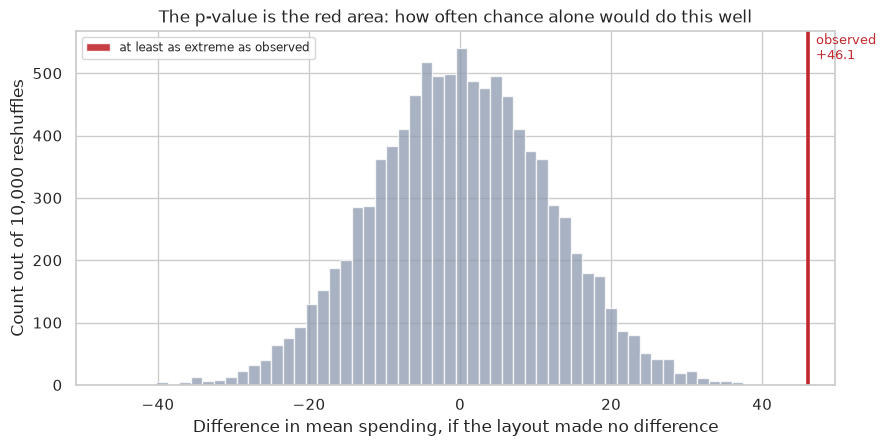

Simulated p-value: 0.0002   (the t-test said 0.0001)


In [57]:
# What the null hypothesis actually predicts — and where our result falls.
null_differences = []
combined = np.concatenate([old_layout, new_layout])
for _ in range(10_000):
    shuffled = rng_test.permutation(combined)
    half = len(old_layout)
    null_differences.append(shuffled[:half].mean() - shuffled[half:].mean())
null_differences = np.array(null_differences)

fig, ax = plt.subplots(figsize=(9.8, 4.6))
ax.hist(null_differences, bins=60, color="#8D99AE", alpha=0.75)
extreme = np.abs(null_differences) >= abs(difference)
ax.hist(null_differences[extreme], bins=60, color="#C1292E", alpha=0.9,
        label="at least as extreme as observed")
ax.axvline(difference, color="#C1292E", linewidth=2.6)
ax.text(difference, ax.get_ylim()[1] * 0.92, f"  observed\n  {difference:+.1f}",
        fontsize=9, color="#C1292E")
ax.set_xlabel("Difference in mean spending, if the layout made no difference")
ax.set_ylabel("Count out of 10,000 reshuffles")
ax.set_title("The p-value is the red area: how often chance alone would do this well")
ax.legend(fontsize=8.5)
plt.show()

print(f"Simulated p-value: {extreme.mean():.4f}   (the t-test said {p_value:.4f})")

**How to read it:** the gray histogram is what the null hypothesis predicts — the differences you would see if
the layout genuinely changed nothing and only the random assignment of customers differed. The red line is
what actually happened. The p-value is the fraction of the gray distribution that is as extreme as the red
line, and the simulation agrees with the formula to three decimals.

### What a p-value is NOT

This is examined constantly and misunderstood constantly, so it is worth stating flatly:

| A p-value is NOT | Why |
|---|---|
| The probability that H₀ is true | It is computed *assuming* H₀ is true |
| The probability your result was a fluke | Same reason |
| A measure of effect size | A tiny, useless difference gets a small p-value if n is large enough |
| Proof of anything | p = 0.049 and p = 0.051 are essentially the same evidence |

**A p-value is:** the probability of seeing data at least this extreme, *if the null hypothesis were true.*
That is all it is.

In [58]:
# Statistical significance is not practical importance.
rng_size = np.random.default_rng(7)

print("A real but trivial effect: the new layout raises spending by 2 baht.")
print("Spending varies by 40 baht (s.d.) around its mean.\n")
print(f"{'Sample size':>12}  {'Observed diff':>14}  {'p-value':>9}  {'Significant?':>13}")
for size in (200, 2_000, 20_000, 200_000):
    a = rng_size.normal(500, 40, size)
    b = rng_size.normal(502, 40, size)         # a genuine 2-baht difference
    _, p = scipy_stats.ttest_ind(b, a)
    print(f"{size:>12,}  {b.mean()-a.mean():>+13.2f}  {p:>9.4f}  "
          f"{'YES' if p < 0.05 else 'no':>13}")

print("\nThe true effect is 2 baht at every sample size. Only the p-value changes.")
print("With enough data, ANY non-zero difference becomes 'statistically significant'.")

A real but trivial effect: the new layout raises spending by 2 baht.
Spending varies by 40 baht (s.d.) around its mean.

 Sample size   Observed diff    p-value   Significant?
         200          +4.10     0.2686             no


       2,000          +2.92     0.0202            YES
      20,000          +1.69     0.0000            YES
     200,000          +1.91     0.0000            YES

The true effect is 2 baht at every sample size. Only the p-value changes.
With enough data, ANY non-zero difference becomes 'statistically significant'.


**How to read it:** the true effect never changes — it is 2 baht throughout, which is commercially
meaningless. What changes is the sample size, and with enough of it the p-value drops below 0.05 and the
result becomes "statistically significant."

**"Significant" is a statistical term, not an English one.** It means "unlikely to be zero," not "large" or
"important." This is why the confidence interval in the previous cell is more informative than the p-value:
an interval of [+1.5, +2.5] baht tells you immediately that the effect is real *and* too small to act on,
which no p-value can.

**Two errors, and the trade-off between them:**

| | H₀ is actually true | H₀ is actually false |
|---|---|---|
| **Reject H₀** | **Type I error** (false positive), rate α | Correct |
| **Do not reject H₀** | Correct | **Type II error** (false negative), rate β |

Setting α = 0.05 means accepting a 1-in-20 false-positive rate. Which connects directly to Section 6.8 and to
Chapter 3's multiple-comparisons warning: **test twenty unrelated hypotheses at α = 0.05 and you should expect
one "significant" result from nothing at all.**

---
## 8. Glossary

| Term | Meaning |
|---|---|
| **Descriptive statistics** | Summarizing the basic features of a dataset |
| **Distribution** | The pattern of how often each value or range occurs |
| **Frequency / relative frequency** | Count in a class / that count as a share of the total |
| **Mean / median / mode** | Sum ÷ count / the middle value / the most common value |
| **Weighted mean** | An average in which observations count unequally |
| **Trimmed mean** | The mean after discarding a fixed share from each end |
| **Skewness** | Asymmetry; a long tail pulls the mean away from the median |
| **Range / IQR** | max − min / Q3 − Q1, the span of the middle 50% |
| **Percentile / quartile** | The value below which p% of the data falls / the 25th, 50th, 75th |
| **Five-number summary** | min, Q1, median, Q3, max — what a boxplot draws |
| **Variance / standard deviation** | Mean squared distance from the mean / its square root |
| **n − 1 (Bessel's correction)** | Divisor that makes the sample variance unbiased |
| **Coefficient of variation** | s / x̄ as a percentage; compares spreads across units |
| **Z-score** | How many standard deviations a value sits from the mean |
| **68–95–99.7 rule** | Share of a normal distribution within 1, 2, and 3 s.d. |
| **Covariance** | Whether two variables are above their means together; unit-dependent |
| **Correlation (Pearson)** | Covariance scaled to [−1, +1]; strength of a *straight-line* relationship |
| **Spearman correlation** | Pearson applied to ranks; measures monotonic relationships |
| **Anscombe's quartet** | Four datasets with identical statistics and different shapes |
| **Experiment / outcome / event** | An uncertain situation / one result / a set of outcomes |
| **Sample space** | The set of all possible outcomes |
| **P(A) = n(A)/n(S)** | Favorable outcomes divided by total outcomes, when equally likely |
| **Mutually exclusive** | Two events that cannot both occur |
| **Independent** | One event's occurrence does not change the other's probability |
| **Conditional probability** | P(A given B) = P(A and B) / P(B) |
| **Bayes' theorem** | posterior = likelihood × prior / evidence |
| **Base rate fallacy** | Ignoring how common something is when interpreting a test result |
| **Binomial / Poisson / normal** | Successes in n trials / events per interval / sums and averages |
| **Central limit theorem** | Sample means become normal regardless of the population's shape |
| **Standard error** | The standard deviation of a sample statistic: s/√n for the mean |
| **Confidence interval** | A range whose construction captures the truth 95% of the time |
| **Null hypothesis (H₀)** | The boring explanation — usually "no difference" |
| **p-value** | P(data this extreme \| H₀ true) — nothing more |
| **Type I / Type II error** | False positive / false negative |
| **Statistical vs. practical significance** | Unlikely to be zero / large enough to matter |

---
## 9. Check your understanding

**Q1.** A class of 30 has a mean salary-expectation of 45,000 baht and a median of 28,000. What does that tell
you?

<details><summary>Answer</summary>

The data is right-skewed — a few very large expectations are dragging the mean above the median. Report the
median as "typical." This is exactly the pattern of the midterm scores in Section 3, where one score of 35
pulled the mean above the median.
</details>

**Q2.** Can you compute the median blood type of a class?

<details><summary>Answer</summary>

No. Blood type is nominal, and a median requires the values to be rankable — there is no sense in which O
lies between A and B. Only the mode applies.
</details>

**Q3.** Group A scores 56, 58, 60, 62, 64; Group B scores 40, 50, 60, 70, 80. Both average 60. Which class
would you rather teach, and what should the teacher report?

<details><summary>Answer</summary>

Group B has five times the spread (s.d. ≈ 15.8 versus 3.16), so it contains both strong students and students
in real difficulty, while Group A is uniform. Reporting only "the class averaged 60" hides the entire
difference — report the standard deviation, or better, the five-number summary.
</details>

**Q4.** Why does the sample standard deviation divide by n − 1?

<details><summary>Answer</summary>

Because deviations are measured from the *sample* mean, which sits in the middle of the sample by
construction, making them systematically too small. Dividing by n − 1 corrects the bias — Section 4.6
demonstrated that dividing by n underestimates the variance by about 20% at n = 5.
</details>

**Q5.** A student scores 72 on an exam with mean 58 and s.d. 11, and 88 on one with mean 84 and s.d. 3. Which
was the better performance?

<details><summary>Answer</summary>

They are close, and z-scores are the only way to tell: (72−58)/11 = +1.27 versus (88−84)/3 = +1.33. The raw
scores are not comparable because the exams had different difficulty and different spread.
</details>

**Q6.** Two variables have correlation 0.82. What have you learned?

<details><summary>Answer</summary>

Very little, until you plot them. All four Anscombe datasets have r = 0.82 and only one is a straight-line
relationship — the others are a curve, a line plus an outlier, and a single leverage point. And even for the
first, correlation is not causation.
</details>

**Q7.** A 99%-accurate test for a disease affecting 1 person in 100 comes back positive. What is the
probability you have it?

<details><summary>Answer</summary>

About 50%. Among a million people, 9,900 sick people test positive and 9,900 healthy people also test
positive, because the healthy group is 99 times larger. This is the base rate fallacy — the prior matters as
much as the test.
</details>

**Q8.** Your data is strongly right-skewed. Can you still use a confidence interval for the mean?

<details><summary>Answer</summary>

Yes, if the sample is reasonably large. The central limit theorem says the *sample mean* is approximately
normal regardless of the population's shape — Section 7.1 demonstrated this with an exponential population.
For very small samples from a very skewed population, be cautious.
</details>

**Q9.** You want to halve the width of your confidence interval. How much more data do you need?

<details><summary>Answer</summary>

Four times as much. The standard error is s/√n, so precision improves with the *square root* of the sample
size. This is why survey sample sizes rarely exceed a couple of thousand — the next halving costs four times
as much as the last.
</details>

**Q10.** A study of 50,000 users finds a 0.3% increase in click-through, p < 0.001. Should you ship it?

<details><summary>Answer</summary>

The p-value says the effect is probably real. It says nothing about whether it is worth having. With 50,000
users almost any non-zero difference becomes "significant" — look at the confidence interval for the effect
*size* and weigh it against the cost of the change. Statistical significance is not practical importance.
</details>

**Q11.** You test 20 different hypotheses at α = 0.05 and one comes back significant. How excited should you
be?

<details><summary>Answer</summary>

Not very. At α = 0.05 you expect one false positive per 20 tests even if nothing is going on. Either correct
for multiple comparisons or, better, confirm the finding on fresh data. This is the same warning as Chapter
3's multiple-comparisons simulation.
</details>

## 10. Summary

| Concept | What it tells you | Python |
|---|---|---|
| Frequency table | how often each value occurs | `value_counts()`, `pd.cut()` for numeric classes |
| Bar / pie chart | a categorical distribution, drawn | `ax.bar()`, `ax.pie()` |
| Histogram | a numerical distribution, drawn | `ax.hist(bins=...)` |
| Mean | the balance point of the data | `.mean()` |
| Median | the middle value (robust to outliers) | `.median()` |
| Mode | the most common value | `.mode()[0]` |
| Standard deviation | typical distance from the mean | `.std()` (divides by n−1) |
| Variance | SD squared | `.var()` |
| Probability | favorable ÷ total outcomes | count with lists / `itertools.product` |

**Formula cheat-sheet:**

| Concept | Formula |
|---|---|
| Relative / percent frequency | $\frac{f}{n}$, $\frac{f}{n}\times 100\%$ |
| Pie slice angle | $\frac{f}{n}\times 360°$ |
| Cumulative frequency / percentage | $CF_i = \sum_{j\le i} f_j$, $\frac{CF_i}{n}\times 100\%$ |
| Mean | $\bar{x} = \frac{1}{n}\sum_{i=1}^n x_i$ |
| Median position | $\frac{n+1}{2}$ |
| Mode | $\arg\max_v f(v)$ |
| Sample standard deviation | $s = \sqrt{\frac{1}{n-1}\sum_{i=1}^n (x_i-\bar{x})^2}$ |
| Variance | $s^2$ |
| Skewness (Pearson) | $Sk = \frac{3(\bar{x}-\text{median})}{s}$ |
| z-score | $z = \frac{x-\bar{x}}{s}$ |
| Probability | $P(A) = \frac{n(A)}{n(S)}$ |
| Counting rule | $n(S) = n_1 \times n_2$ |
| Law of large numbers | $\lim_{n\to\infty}\frac{f_A}{n} = P(A)$ |

### New in the expanded sections

| Concept | What it tells you | Python |
|---|---|---|
| Weighted / trimmed mean | an average with unequal weights / with the extremes discarded | `(x*w).sum()/w.sum()` |
| Quartiles, IQR, five-number summary | spread that ignores outliers | `.quantile()`, `.describe()` |
| Coefficient of variation | spread relative to the variable's own scale | `s / mean * 100` |
| Covariance / correlation | do two variables move together, and how tightly | `.cov()`, `.corr()` |
| Spearman correlation | a monotonic (not necessarily straight) relationship | `.corr(method="spearman")` |
| Conditional probability, Bayes | how evidence should update a belief | arithmetic, or `scipy.stats` |
| Binomial / Poisson / normal | named distributions and their exact probabilities | `scipy.stats.<dist>.pmf/cdf/ppf` |
| Standard error | the standard deviation of a sample mean | `s / np.sqrt(n)` |
| Confidence interval | the range the data actually supports | `mean ± 1.96 * SE` |
| p-value | P(data this extreme, if H₀ were true) | `scipy.stats.ttest_ind` |

| Concept | Formula |
|---|---|
| Weighted mean | $\bar{x}_w = \frac{\sum w_i x_i}{\sum w_i}$ |
| Interquartile range | $IQR = Q_3 - Q_1$ |
| Coefficient of variation | $CV = \frac{s}{\bar{x}} \times 100\%$ |
| Covariance | $\text{cov}(x,y) = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})}{n-1}$ |
| Correlation | $r = \frac{\text{cov}(x,y)}{s_x s_y}$ |
| Complement / addition | $P(\bar{A}) = 1-P(A)$;  $P(A\cup B)=P(A)+P(B)-P(A\cap B)$ |
| Conditional probability | $P(A\mid B) = \frac{P(A\cap B)}{P(B)}$ |
| Bayes' theorem | $P(A\mid B) = \frac{P(B\mid A)P(A)}{P(B)}$ |
| Standard error of the mean | $SE = \frac{s}{\sqrt{n}}$ |
| 95% confidence interval | $\bar{x} \pm 1.96\,\frac{s}{\sqrt{n}}$ |

### The ten things worth carrying out of this chapter

1. **Mean ≠ typical.** A single extreme value can drag the mean away from what most of the data looks like.
2. **Median resists outliers.** Sorting and taking the middle is far less sensitive to one wild value.
3. **Mode works on categories** — the only central-tendency measure needing no ranking or arithmetic.
4. **Same mean, different story.** Always check the spread; standard deviation reveals what the mean hides.
5. **Skew splits the three.** Mean, median, and mode line up only when the distribution is symmetric.
6. **A raw number means nothing without its distribution.** That is what z-scores are for.
7. **Always plot the data.** Anscombe's quartet: four datasets, identical statistics, four different shapes.
8. **Probability is careful counting** — P(A) = n(A)/n(S) — until events stop being independent, at which
   point you need the conditional rules.
9. **The prior matters as much as the evidence.** A 99% accurate test for a 1-in-100 disease still leaves a
   positive result at 50/50.
10. **Report an interval, not a point.** And remember that "statistically significant" means "probably not
    zero," never "large enough to matter."

### Where this goes next

- **Chapter 9 — Machine Learning**: training and test sets are a sampling problem; the central limit theorem
  is why a test-set score is an estimate with uncertainty.
- **Chapter 10 — Supervised Learning**: regression is correlation with a direction and a prediction attached.
- **Chapter 11 — Unsupervised Learning**: distance and variance, from Section 4, are what clustering
  optimizes.

Now it's your turn. 👇

## 11. Homework 📝

**Instructions**

- Complete all **6 exercises** (plus the bonus if you want an extra challenge).
- Write your code in the empty cells below each question — replace `# YOUR CODE HERE`.
- Every chart must have a **title** and **axis labels**.
- Answer the short interpretation questions **in the markdown cell** provided
  (double-click the cell to edit, `Shift + Enter` when done).
- When finished: `File ▸ Save`, then submit this `.ipynb` file.

First, fill in your details:


### 👤 Student information

- **Name:** *(double-click here and type your name)*
- **Student ID:**
- **Date:**


### The homework dataset — 🍜 Night Market Noodles

You are analyzing one month of sales from *Night Market Noodles*, a food stall
with two branches in Chiang Mai. Run the cell below to create the dataset (do
**not** modify it). It contains **240 orders** with these columns:

| Column | Meaning | Type |
|---|---|---|
| `branch` | Old City or Nimman | categorical (nominal) |
| `dish` | Khao Soi, Pad Thai, Boat Noodles, Wonton | categorical (nominal) |
| `rating` | Poor / Average / Good / Excellent | categorical (ordinal) |
| `amount` | order amount (baht) | numerical |


In [59]:
# ------- RUN THIS CELL, BUT DO NOT MODIFY IT -------
rng = np.random.default_rng(888102)
n = 240

branch = rng.choice(["Old City", "Nimman"], n)
dish = rng.choice(["Khao Soi", "Pad Thai", "Boat Noodles", "Wonton"],
                  n, p=[0.40, 0.25, 0.20, 0.15])
rating = rng.choice(["Poor", "Average", "Good", "Excellent"],
                    n, p=[0.10, 0.30, 0.45, 0.15])

# Both branches average ~80 baht per order, but one is much more variable...
amount = np.where(branch == "Old City",
                  rng.normal(80, 8, n),      # steady prices
                  rng.normal(80, 25, n))     # specials, discounts, big groups
amount = amount.clip(20, 160).round(0)

orders = pd.DataFrame({"branch": branch, "dish": dish,
                       "rating": rating, "amount": amount})
print("Dataset created:", orders.shape[0], "orders")
orders.head()

Dataset created: 240 orders


,branch,dish,rating,amount
0,Nimman,Pad Thai,Good,71.0
1,Nimman,Boat Noodles,Good,65.0
2,Nimman,Khao Soi,Good,90.0
3,Nimman,Pad Thai,Excellent,67.0
4,Nimman,Khao Soi,Good,78.0


---
### Exercise 1 — Frequency distribution (categorical)

Build the full frequency table of the `dish` column, with three columns like the
lecture's hotel example: **Frequency**, **Relative Frequency**, and **Percent
Frequency** (hint: `value_counts()`, then divide by the total). Add a "Total" row.

**Question 1:** Which dish is the best seller, and what percentage of all orders
does it represent?


In [60]:
# YOUR CODE HERE (Exercise 1)


**✍️ Your answer to Question 1:** *(double-click to edit)*

---
### Exercise 2 — Bar chart and pie chart

Draw the `dish` distribution from Exercise 1 as **(a)** a bar chart with the
count written on top of each bar (hint: `ax.bar_label(...)`) and **(b)** a pie
chart with percentages (hint: `autopct="%1.0f%%"`).

**Question 2:** Which of the two charts makes it easier to compare Pad Thai
against Boat Noodles? Why?


In [61]:
# YOUR CODE HERE (Exercise 2)


**✍️ Your answer to Question 2:**

---
### Exercise 3 — Frequency distribution (numerical)

Group the `amount` column into classes of **width 20 baht** starting at 20
(20–39, 40–59, …, 140–159), following the lecture's three steps
(hint: `pd.cut(orders["amount"], bins=range(20, 180, 20), right=False)`).
Produce the table with Frequency, Cumulative frequency, Relative Frequency, and
Percentage — then draw the histogram with the same bins.

**Question 3:** Which class contains the most orders? What percentage of orders
cost **less than 100 baht** (read your cumulative column)?


In [62]:
# YOUR CODE HERE (Exercise 3)


**✍️ Your answer to Question 3:**

---
### Exercise 4 — Mean, median, and mode

1. Compute the **mean**, **median**, and **mode** of `amount` for all 240 orders.
2. Draw a histogram of `amount` and mark the mean and median as vertical lines
   (hint: `ax.axvline(...)`).

**Question 4:** Are the mean and median close together or far apart? What does
that tell you about the skewness of the amounts (compare section 2.5)?


In [63]:
# YOUR CODE HERE (Exercise 4)


**✍️ Your answer to Question 4:**

---
### Exercise 5 — Standard deviation and variance

1. Compute the **mean**, **standard deviation**, and **variance** of `amount`
   separately for each branch
   (hint: `orders.groupby("branch")["amount"].agg(["mean", "std", "var"])`).
2. Draw one boxplot of `amount` per branch to show the difference
   (hint: `sns.boxplot(data=orders, x="branch", y="amount")`).

**Question 5:** Both branches have nearly the same mean — so which branch has the
more *predictable* prices, and how do the SD values prove it? (This is exactly
the lecture's Group A vs. Group B story.)


In [64]:
# YOUR CODE HERE (Exercise 5)


**✍️ Your answer to Question 5:**

---
### Exercise 6 — Probability

1. **From the data:** estimate the probability that a randomly chosen order is
   rated "Excellent" — n(Excellent) ÷ n(all orders).
2. **From theory:** using `itertools.product`, list all outcomes of throwing two
   dice and compute P(sum = 7).
3. **By simulation:** simulate 10,000 throws of two dice with
   `rng.integers(1, 7, size=(10000, 2))`, estimate P(sum = 7) from the relative
   frequency, and compare with your theoretical answer.

**Question 6:** How close is the simulated probability to the theoretical one?
What would you expect to happen with 1,000,000 throws instead?


In [65]:
# YOUR CODE HERE (Exercise 6)


**✍️ Your answer to Question 6:**

---
### Bonus — The 68% check 🚀

The lecture's normal curve says about **68%** of values fall within ±1 SD of the
mean. Test it on the *Old City* branch: compute the share of Old City orders
whose `amount` lies between mean − SD and mean + SD. Then do the same for the
*Nimman* branch.

**Bonus question:** Are the two shares close to 68%? Why does the rule work here
even though noodle prices are not a perfect bell curve?


In [66]:
# YOUR CODE HERE (Bonus)


**✍️ Your answer to the bonus question:**

---
🎉 **Well done!** You have practiced the full Chapter 8 toolkit: frequency
distributions for categorical and numerical data, bar/pie charts and histograms,
mean–median–mode, standard deviation and variance, and probability by counting
**and** by simulation.

**Checklist before submitting:**

- [ ] Every cell runs without errors (`Kernel ▸ Restart & Run All` is a good final test)
- [ ] Every chart has a title and axis labels
- [ ] All six ✍️ answers are filled in
- [ ] Your name and student ID are at the top of the homework section
